# 🤖 Project Budget & Duration Predictor
Predicts **final_budget_usd** and from project features.

Prices are normalized to **USD** (via the daily `usd_rate`) instead of raw IRR,
since IRR has been too unstable over this dataset's ~15-year span to be a
meaningful regression target on its own.

Sections:
1. Load & inspect
2. Target engineering (USD normalization, null handling, log transform)
3. Sample weighting types
4. Feature engineering & encoding
5. Train models — classical ML CatBoost
6. Train a deep learning model (feed-forward neural net)
7. Analysis
8. Feature importance (classical models)
9. SHAP — per-prediction explanations
10. Use embedding

In [13]:
import warnings, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import shap
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
warnings.filterwarnings('ignore')
tf.random.set_seed(42)

plt.rcParams.update({
    'figure.dpi': 130, 'font.family': 'sans-serif',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
})
ACCENT, ACCENT2 = '#5B8DEF', '#F4845F'

# ── Paths ────────────────────────────────────────────────────────────────
CSV_PATH = Path('../ml_dataset/full_dataset.csv')   # <-- adjust if needed
# CSV_PATH = Path('/absolute/path/to/full_dataset.csv')

BUDGET_RATIO_THRESHOLD = 3.0  # max/min ratio to accept imputed budget (avg of min/max)

# Only rows with a resolvable USD exchange rate can have a USD target.
# (build_dataset.py already computes this from the nearest available
# daily rate, average of open/high/low/close, keyed off scraped_date_created.)
REQUIRE_USD_RATE = True

ENUM_COLS = [
    'project_type', 'ai_level', 'business_logic', 'data_volume',
    'integration_complexity', 'ui_complexity', 'algorithmic_complexity'
]
# Columns that are not model inputs
NON_FEATURE = [
    'project_id','title','category','organization','created_at','scraped_date_created',
    'final_budget','log_final_budget','budget_min','budget_max','log_budget_min','log_budget_max',
    'budget_range','budget_range_ratio','has_final_budget','duration',
    'description','skills','outer_link','updated_at','category_scraped_id','description_length',
     'description_word_count', 'skill_count',
    "website","web_application",
      "mobile_application","desktop_application",
      "api_backend","ecommerce",
      "marketplace","cms","crm","erp",
      "lms","booking_system",
      "social_network","media_platform",
      "financial_system","healthcare_system",
      "real_estate_platform","automation_system",
      "iot_system","ai_application",
      "browser_extension","other",
    #   'external_api_count','estimated_screens','estimated_entities',
    #   'requires_refactoring','requires_reverse_engineering','cross_platform',
    'ai_level','business_logic','data_volume','integration_complexity','ui_complexity','algorithmic_complexity',
    'feature_score_sum',
    # 'feature_count',
    'feature_score_mean','feature_score_max',

    # USD normalization columns (rate + amounts) — inputs to target engineering,
    # not model features themselves
    'usd_rate','usd_rate_date','final_budget_usd','log_final_budget_usd',
    'budget_min_usd','budget_max_usd','log_budget_min_usd','log_budget_max_usd',
    'budget_range_usd',
    # derived targets added later
    'target_budget','is_budget_imputed','is_days_null',
    'log_target_budget',
]


def interval_accuracy(y_true_log, y_pred_log, pct=0.20):
    """
    Percentage of predictions within ±pct of the true price.
    Inputs are log1p(price).
    """

    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    rel_error = np.abs(y_pred - y_true) / np.maximum(y_true, 1)

    return np.mean(rel_error <= pct)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

df_raw = pd.read_csv(CSV_PATH)
print(f'✅  {len(df_raw):,} rows  ·  {df_raw.shape[1]} columns')
print(f'    Organizations: {df_raw.organization.unique()}')

if REQUIRE_USD_RATE and 'usd_rate' in df_raw.columns:
    n_no_rate = df_raw['usd_rate'].isna().sum()
    print(f'    Rows with no usable USD rate (dropped before modeling): '
          f'{n_no_rate:,} ({n_no_rate/len(df_raw):.1%})')

df_raw.head(2)
print(df_raw.columns.tolist())

✅  19,668 rows  ·  164 columns
    Organizations: <StringArray>
['Karlancer', 'Ponisha']
Length: 2, dtype: str
    Rows with no usable USD rate (dropped before modeling): 0 (0.0%)
['project_id', 'title', 'category', 'organization', 'outer_link', 'created_at', 'scraped_date_created', 'usd_rate', 'usd_rate_date', 'final_budget', 'log_final_budget', 'final_budget_usd', 'log_final_budget_usd', 'budget_min', 'budget_max', 'log_budget_min', 'log_budget_max', 'budget_min_usd', 'budget_max_usd', 'log_budget_min_usd', 'log_budget_max_usd', 'budget_range_usd', 'budget_range_ratio', 'has_final_budget', 'duration', 'duration_days', 'description_length', 'description_word_count', 'skill_count', 'skills', 'description', 'Authentication', 'Authorization & Role Management', 'User Management', 'User Profiles', 'Infrastructure & Operations', 'Administration Panel', 'Dashboard', 'Settings & Configuration', 'Content Management', 'Rich Text Editing', 'Media Management', 'Forms & Data Collection', 'File Upl

## 2 · Target engineering
**USD normalization:** every budget figure is converted from IRR to USD using
`usd_rate` (nearest available daily rate) *before* any null-handling. Rows with
no resolvable `usd_rate` are dropped — we can't meaningfully price a project
without knowing what its IRR figure was worth at the time.

**Budget null rule:** if `final_budget_usd` is null and `budget_max_usd / budget_min_usd ≤ threshold` → use average of min/max. Otherwise drop the row.

**Duration null rule:** fill with dataset median, add `is_days_null` flag so the model knows the value was imputed.

Rows dropped (no USD rate): 0
Rows before: 19,668  |  dropped (ratio too high): 3070  |  kept: 16,598
Budget imputed (avg min/max): 3773
Duration filled with median (7 days): 6797



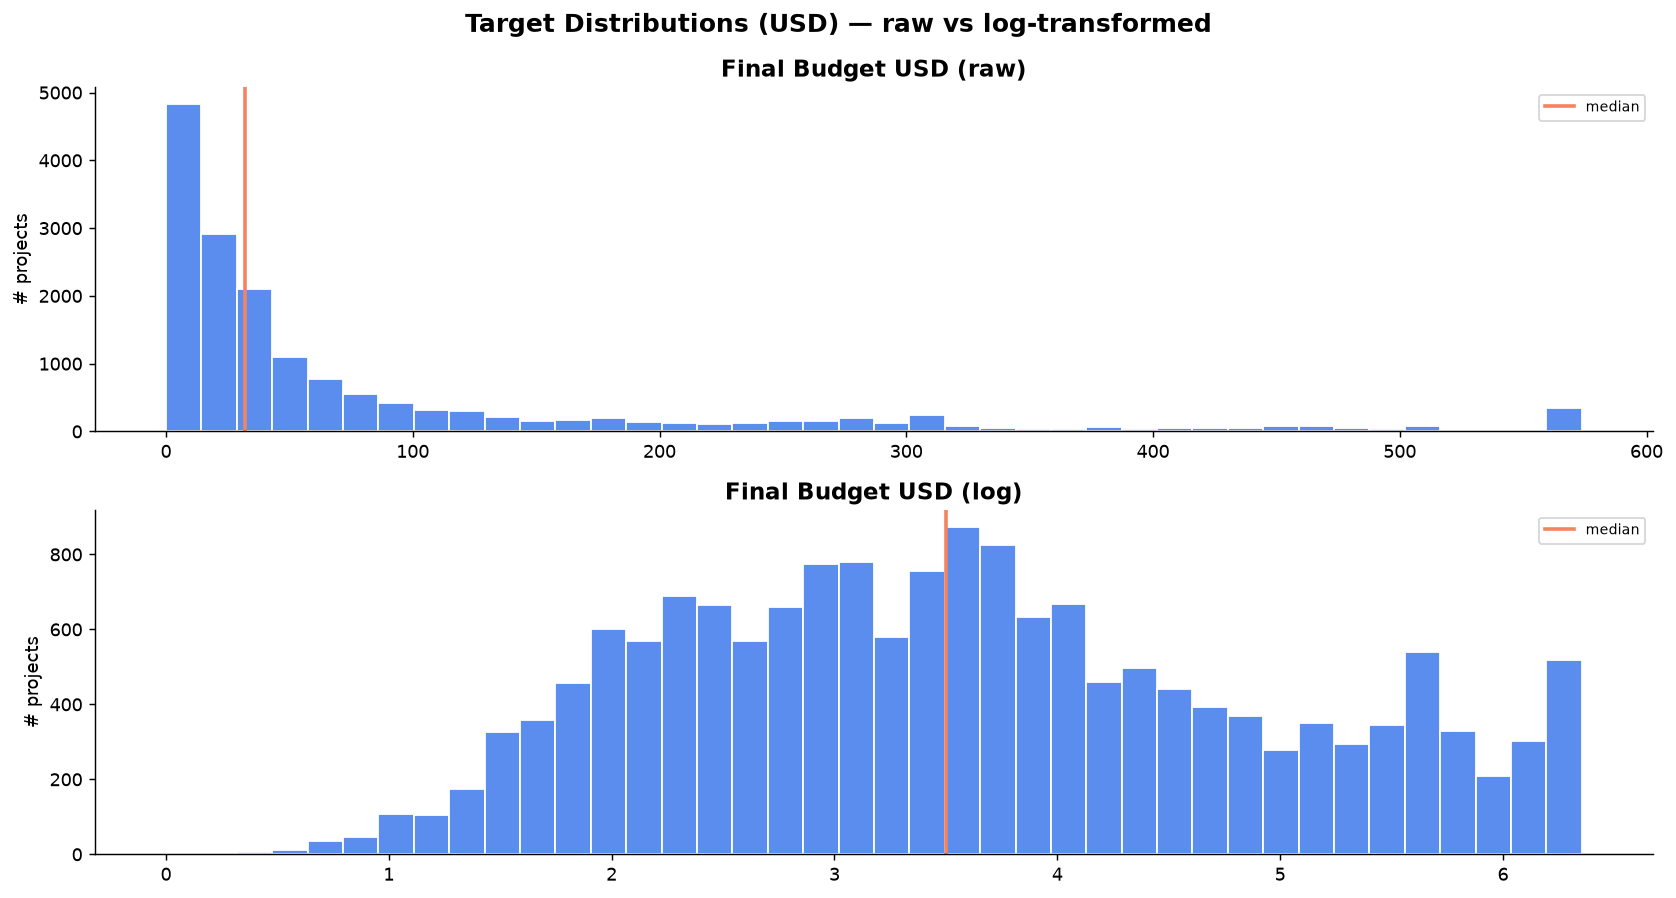

In [14]:
# Drop rows with no usable USD rate first — everything downstream is USD-denominated.
df = df_raw[df_raw['usd_rate'].notna()].copy() if REQUIRE_USD_RATE else df_raw.copy()
n_dropped_no_rate = len(df_raw) - len(df)
PCT_THRESHOLD = 0.10
PRICE_THRESHOLD_UP = 1000000
PRICE_THRESHOLD_DOWN = 0
# ── Budget (USD) ─────────────────────────────────────────────────────────
def resolve_final_budget(row):
    if row['final_budget_usd'] > PRICE_THRESHOLD_UP or row['final_budget_usd'] < PRICE_THRESHOLD_DOWN :
        return np.nan, False 
    if pd.notna(row['final_budget_usd']) and row["final_budget_usd"] != 0 and not row['final_budget_usd'] < row['budget_min_usd'] * (1 - PCT_THRESHOLD):
        return row['final_budget_usd'], False   # (value, is_imputed)
    ratio = row['budget_max_usd'] / max(row['budget_min_usd'], 1e-6)
    if ratio <= BUDGET_RATIO_THRESHOLD:
        estimated_final_price =  (row['budget_min_usd'] + row['budget_max_usd']) / 2
        if estimated_final_price > PRICE_THRESHOLD_UP or estimated_final_price < PRICE_THRESHOLD_DOWN :
            return np.nan, False 
        return estimated_final_price, True
    # return np.nan, False   # ratio too high → will be dropped

df[['target_budget', 'is_budget_imputed']] = df.apply(
    lambda r: pd.Series(resolve_final_budget(r)), axis=1
)
before = len(df)
df = df[df['target_budget'].notna()].copy()
dropped = before - len(df)

# ── Duration ─────────────────────────────────────────────────────────────
duration_median = df['duration_days'].median()
df['is_days_null'] = df['duration_days'].isna().astype(int)
df['duration_days'] = df['duration_days'].fillna(duration_median)

# ── Log-transform targets (right-skewed money/time values) ────────────────
df['log_target_budget']   = np.log1p(df['target_budget'])

print(f'Rows dropped (no USD rate): {n_dropped_no_rate:,}')
print(f'Rows before: {before:,}  |  dropped (ratio too high): {dropped}  |  kept: {len(df):,}')
print(f'Budget imputed (avg min/max): {df.is_budget_imputed.sum()}')
print(f'Duration filled with median ({duration_median:.0f} days): {df.is_days_null.sum()}')
print()

fig, axes = plt.subplots(2, 1, figsize=(13, 7))
for ax, col, label in [
    (axes[0], 'target_budget',       'Final Budget USD (raw)'),
    (axes[1], 'log_target_budget',   'Final Budget USD (log)'),
]:
    ax.hist(df[col].clip(upper=df[col].quantile(0.98)), bins=40, color=ACCENT, edgecolor='white')
    ax.axvline(df[col].median(), color=ACCENT2, linewidth=2, label='median')
    ax.set_title(label); ax.set_ylabel('# projects'); ax.legend(fontsize=8)
fig.suptitle('Target Distributions (USD) — raw vs log-transformed', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 3. Sample Weighting Types

In [15]:
import json
import numpy as np
import pandas as pd

# ============================================================
# Load confidence feature names from taxonomy
# ============================================================

with open("taxonomy/taxonomy.json", "r", encoding="utf-8") as f:
    taxonomy = json.load(f)

CONFIDENCE_FEATURES = [
    c for c in list(taxonomy["features"]["values"])
    if c in df_raw.columns
]

print(df_raw.columns)

print(f"Found {len(CONFIDENCE_FEATURES)} confidence features.")

# ============================================================
# Confidence preprocessing
# ============================================================

# Available modes:
#
# A      -> Keep original (0,1,2,3,4,5)
# B      -> Remove weak detections (1,2 -> 0)
# C      -> Binary presence (3,4,5 -> 1)
# MAP    -> Manual nonlinear mapping
# POWER  -> (confidence / 5)^2

CONFIDENCE_MAP = {
    0: 0.00,
    1: 0.02,
    2: 0.08,
    3: 0.35,
    4: 0.75,
    5: 1.00,
}


def transform_confidence(df, mode="A"):
    """
    Transform only taxonomy confidence features.

    Parameters
    ----------
    df : pandas.DataFrame

    mode : str
        "A"      -> original
        "B"      -> 1,2 become 0
        "C"      -> binary (>=3 -> 1)
        "MAP"    -> manual nonlinear mapping
        "POWER"  -> (x/5)^2

    Returns
    -------
    pandas.DataFrame
    """

    df = df.copy()

    mode = mode.upper()

    if mode == "A":
        pass

    elif mode == "B":

        df[CONFIDENCE_FEATURES] = df[CONFIDENCE_FEATURES].replace({
            1: 0,
            2: 0,
        })

    elif mode == "C":

        df[CONFIDENCE_FEATURES] = (
            df[CONFIDENCE_FEATURES] >= 3
        ).astype(np.int8)

    elif mode == "MAP":

        df[CONFIDENCE_FEATURES] = (
            df[CONFIDENCE_FEATURES]
            .replace(CONFIDENCE_MAP)
            .astype(np.float32)
        )

    elif mode == "POWER":

        df[CONFIDENCE_FEATURES] = (
            (df[CONFIDENCE_FEATURES] / 5.0) ** 2
        ).astype(np.float32)

    else:
        raise ValueError(f"Unknown mode '{mode}'")

    return df

Index(['project_id', 'title', 'category', 'organization', 'outer_link',
       'created_at', 'scraped_date_created', 'usd_rate', 'usd_rate_date',
       'final_budget',
       ...
       'data_volume', 'integration_complexity', 'ui_complexity',
       'algorithmic_complexity', 'updated_at', 'category_scraped_id',
       'feature_score_sum', 'feature_count', 'feature_score_mean',
       'feature_score_max'],
      dtype='str', length=164)
Found 82 confidence features.


## 4 · Feature engineering & encoding

In [16]:


# ============================================================
# Ordered categorical columns
# ============================================================

PROJECT_TYPE_COL = "project_type"

ORDINAL_COLS = [
    "ai_level",
    "business_logic",
    "data_volume",
    "integration_complexity",
    "ui_complexity",
    "algorithmic_complexity",
]

ENUM_ORDER = {
    "ai_level": ["none", "basic", "advanced"],
    "business_logic": ["low", "medium", "high"],
    "data_volume": ["small", "medium", "large"],
    "integration_complexity": ["low", "medium", "high"],
    "ui_complexity": ["low", "medium", "high"],
    "algorithmic_complexity": ["low", "medium", "high"],
}

# ============================================================
# Keep only columns that exist and are used as features
# ============================================================

ordinal_cols_present = [
    c for c in ORDINAL_COLS
    if c in df.columns and c not in NON_FEATURE
]

project_type_present = (
    [PROJECT_TYPE_COL]
    if PROJECT_TYPE_COL in df.columns and PROJECT_TYPE_COL not in NON_FEATURE
    else []
)

cols_to_clean = ordinal_cols_present + project_type_present

# ============================================================
# Normalize string values
# ============================================================

if cols_to_clean:
    df[cols_to_clean] = (
        df[cols_to_clean]
        .astype(str)
        .apply(lambda s: s.str.strip().str.lower())
    )

# ============================================================
# Show values before encoding
# ============================================================

print("=== Enum values before encoding ===")

for col in cols_to_clean:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False).head(20))

# ============================================================
# Ordinal encode ordered columns
# ============================================================

if ordinal_cols_present:

    enc = OrdinalEncoder(
        categories=[ENUM_ORDER[c] for c in ordinal_cols_present],
        handle_unknown="use_encoded_value",
        unknown_value=-1,
    )

    df[ordinal_cols_present] = enc.fit_transform(
        df[ordinal_cols_present]
    )

# ============================================================
# One-hot encode project_type
# ============================================================

if project_type_present:

    df = pd.get_dummies(
        df,
        columns=project_type_present,
        prefix="project_type",
        dtype=np.int8,
    )

# ============================================================
# Build feature list
# ============================================================

ALL_FEATURES = [
    c
    for c in df.columns
    if c not in NON_FEATURE and df[c].dtype != object
]

print(f"\nNumber of features: {len(ALL_FEATURES)}")

# ============================================================
# Prepare train/test
# ============================================================
MODE="A"
df_model = transform_confidence(df, MODE)

X = df_model[ALL_FEATURES]
yB = df_model["log_target_budget"]

# First split: separate out test (held out, touched once)
X_temp, X_te, yB_temp, yB_te = train_test_split(
    X,
    yB,
    test_size=0.15,
    random_state=42,
)

# Second split: divide remainder into train / validation
X_tr, X_val, yB_tr, yB_val = train_test_split(
    X_temp,
    yB_temp,
    test_size=0.1765,  # 0.1765 * 0.85 ≈ 0.15 → 70/15/15 overall
    random_state=42,
)

print(f"Train: {len(X_tr)} ({len(X_tr)/len(X):.1%})")
print(f"Val:   {len(X_val)} ({len(X_val)/len(X):.1%})")
print(f"Test:  {len(X_te)} ({len(X_te)/len(X):.1%})")

print(X_te.head(2))

=== Enum values before encoding ===

project_type
project_type
new             9457
maintenance     3886
bugfix          1732
optimization     668
migration        446
consulting       390
testing           19
Name: count, dtype: int64

Number of features: 107
Train: 11617 (70.0%)
Val:   2491 (15.0%)
Test:  2490 (15.0%)
       duration_days  Authentication  Authorization & Role Management  \
11404            1.0               0                                0   
5598            15.0               4                                0   

       User Management  User Profiles  Infrastructure & Operations  \
11404                0              0                            0   
5598                 4              4                            0   

       Administration Panel  Dashboard  Settings & Configuration  \
11404                     0          0                         1   
5598                      0          0                         0   

       Content Management  Rich Text Editi

## Linear Regression


LinearRegression_None
Weight mode    : none
Train R²       : 0.2268
Test  R²       : 0.2096
RMSE (log)     : 0.8005
MAE            : 16
Coverage ±10% : 8.72%
Coverage ±20% : 17.80%
Coverage ±30% : 26.00%
Coverage ±50% : 46.11%


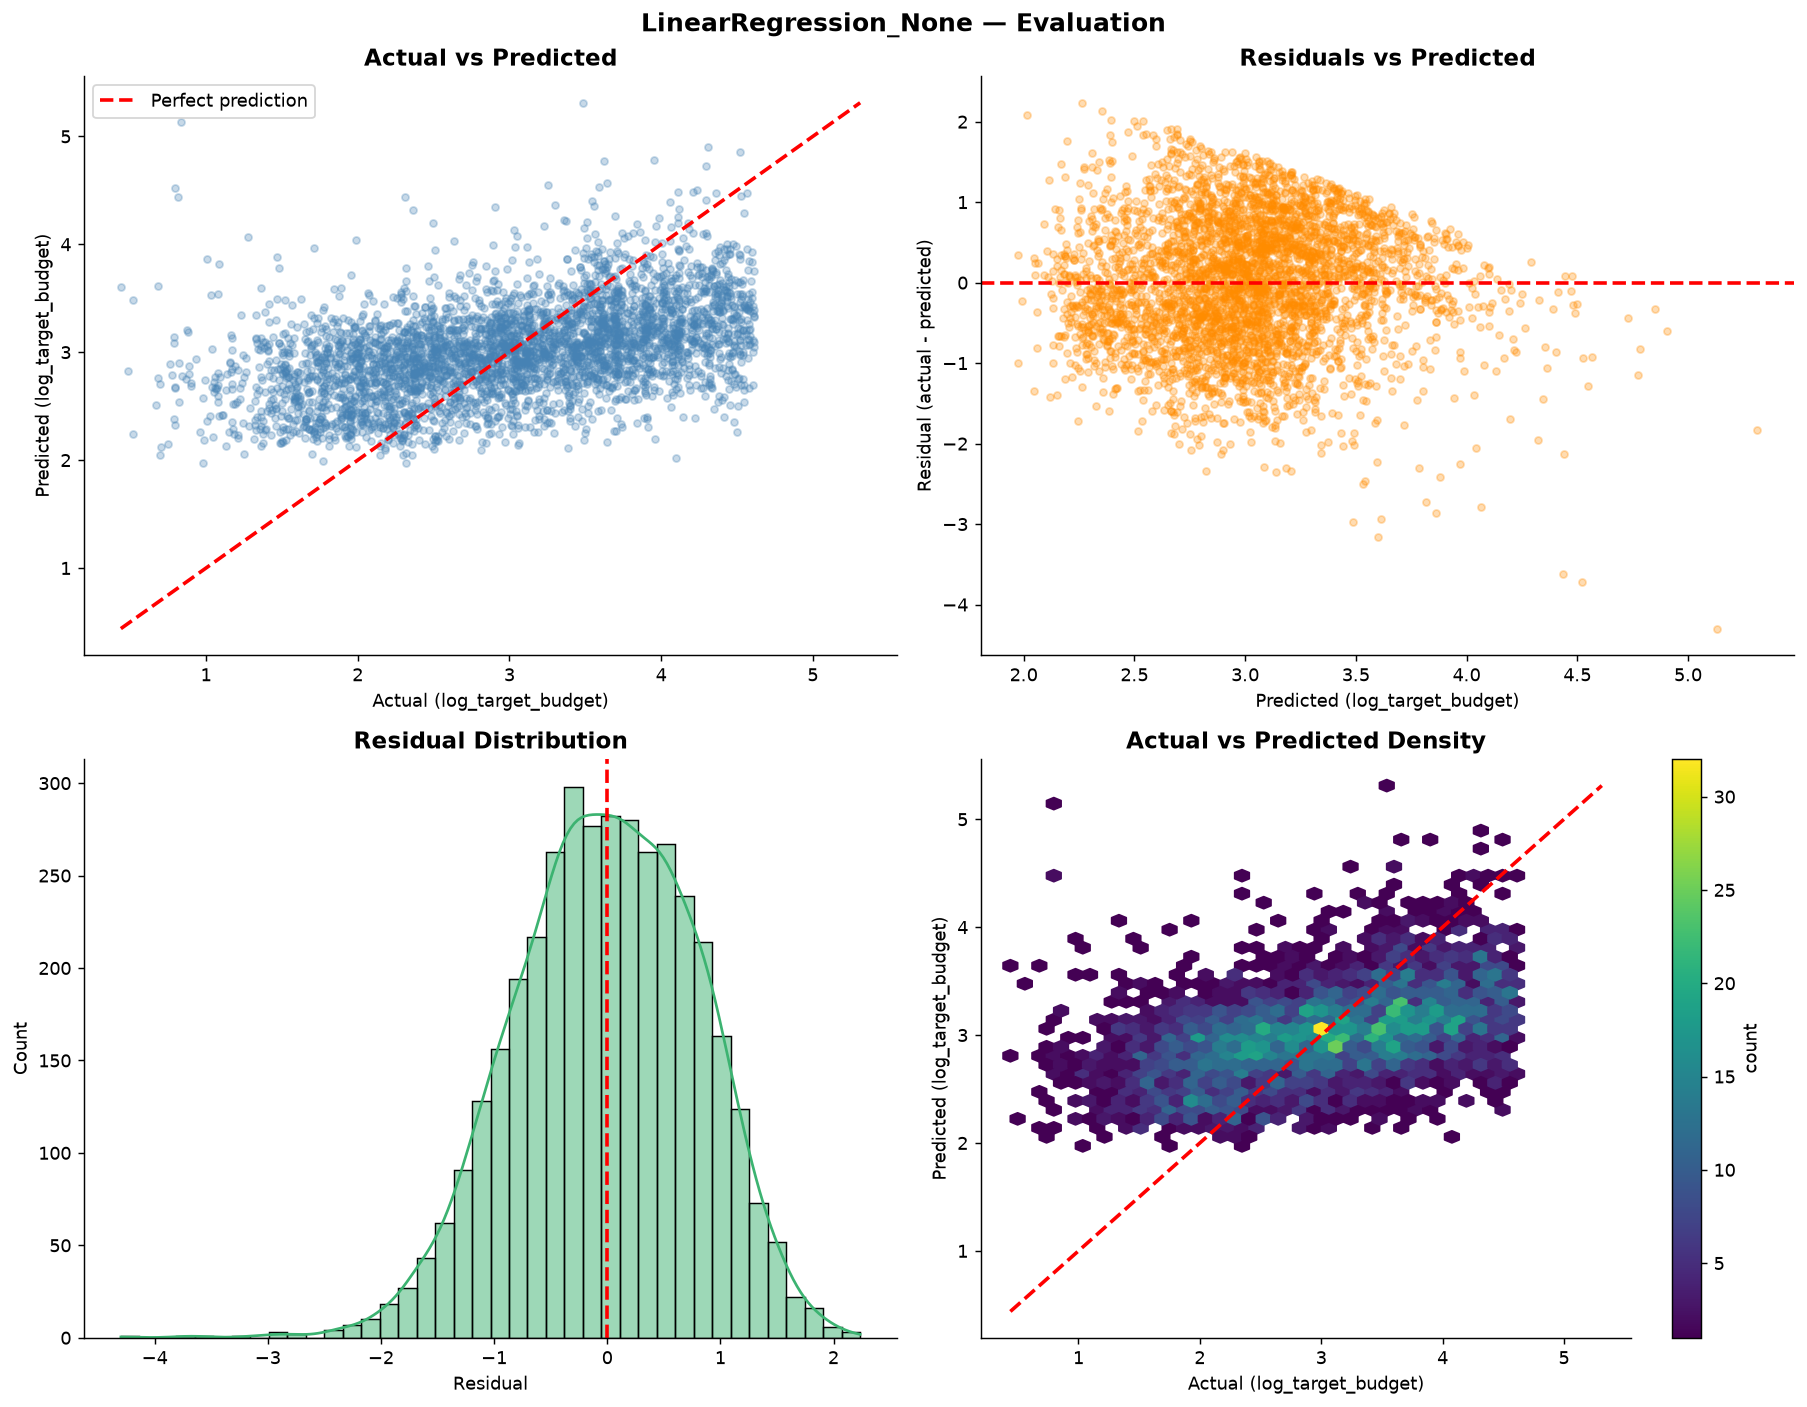

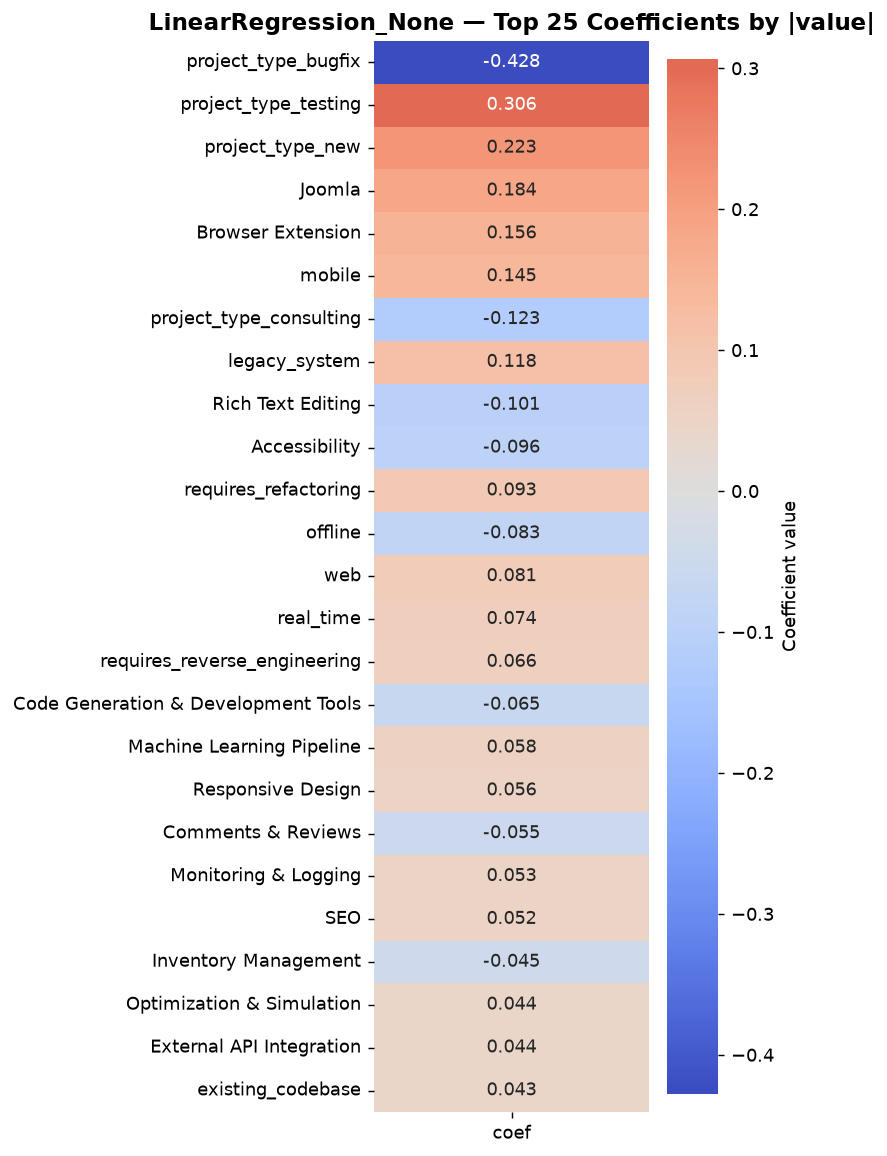

In [17]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Train + Evaluate Linear Regression
# ============================================================

def evaluate_linreg(
    X_tr,
    y_tr,
    X_te,
    y_te,
    name,
    weight_mode="sqrt",   # none | log | sqrt | linear
):

    # --------------------------------------------------------
    # Sample weights (same logic as CatBoost version)
    # --------------------------------------------------------

    budget_train = np.expm1(y_tr)

    if weight_mode == "none":
        sample_weight = None
    elif weight_mode == "log":
        sample_weight = np.log1p(budget_train)
    elif weight_mode == "sqrt":
        sample_weight = np.sqrt(budget_train + 1)
    elif weight_mode == "linear":
        sample_weight = budget_train
    else:
        raise ValueError("Unknown weight mode")

    if sample_weight is not None:
        sample_weight = sample_weight / sample_weight.mean()

    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    model = LinearRegression()

    model.fit(
        X_tr,
        y_tr,
        sample_weight=sample_weight,
    )

    # --------------------------------------------------------
    # Predict
    # --------------------------------------------------------

    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    mae_te = mean_absolute_error(np.expm1(y_te), np.expm1(pred_te))
    rmse_te = np.sqrt(mean_squared_error(y_te, pred_te))
    r2_tr = r2_score(y_tr, pred_tr)
    r2_te = r2_score(y_te, pred_te)

    print()
    print("=" * 70)
    print(name)
    print("=" * 70)
    print(f"Weight mode    : {weight_mode}")
    print(f"Train R²       : {r2_tr:.4f}")
    print(f"Test  R²       : {r2_te:.4f}")
    print(f"RMSE (log)     : {rmse_te:.4f}")
    print(f"MAE            : {mae_te:,.0f}")

    cov10 = interval_accuracy(y_te, pred_te, 0.10)
    cov20 = interval_accuracy(y_te, pred_te, 0.20)
    cov30 = interval_accuracy(y_te, pred_te, 0.30)
    cov50 = interval_accuracy(y_te, pred_te, 0.50)

    print(f"Coverage ±10% : {cov10:.2%}")
    print(f"Coverage ±20% : {cov20:.2%}")
    print(f"Coverage ±30% : {cov30:.2%}")
    print(f"Coverage ±50% : {cov50:.2%}")

    # --------------------------------------------------------
    # Plots
    # --------------------------------------------------------

    residuals = y_te - pred_te

    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    fig.suptitle(f"{name} — Evaluation", fontsize=14, fontweight="bold")

    # 1) Actual vs Predicted (log target)
    ax = axes[0, 0]
    ax.scatter(y_te, pred_te, alpha=0.3, s=15, color="steelblue")
    lims = [min(y_te.min(), pred_te.min()), max(y_te.max(), pred_te.max())]
    ax.plot(lims, lims, "r--", lw=2, label="Perfect prediction")
    ax.set_xlabel("Actual (log_target_budget)")
    ax.set_ylabel("Predicted (log_target_budget)")
    ax.set_title("Actual vs Predicted")
    ax.legend()

    # 2) Residuals vs Predicted
    ax = axes[0, 1]
    ax.scatter(pred_te, residuals, alpha=0.3, s=15, color="darkorange")
    ax.axhline(0, color="red", linestyle="--", lw=2)
    ax.set_xlabel("Predicted (log_target_budget)")
    ax.set_ylabel("Residual (actual - predicted)")
    ax.set_title("Residuals vs Predicted")

    # 3) Residual distribution
    ax = axes[1, 0]
    sns.histplot(residuals, bins=40, kde=True, ax=ax, color="mediumseagreen")
    ax.axvline(0, color="red", linestyle="--", lw=2)
    ax.set_xlabel("Residual")
    ax.set_title("Residual Distribution")

    # 4) Actual vs Predicted density heatmap (hexbin)
    ax = axes[1, 1]
    hb = ax.hexbin(y_te, pred_te, gridsize=35, cmap="viridis", mincnt=1)
    ax.plot(lims, lims, "r--", lw=2)
    ax.set_xlabel("Actual (log_target_budget)")
    ax.set_ylabel("Predicted (log_target_budget)")
    ax.set_title("Actual vs Predicted Density")
    fig.colorbar(hb, ax=ax, label="count")

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Coefficient heatmap (top N by |coef|)
    # --------------------------------------------------------

    if hasattr(X_tr, "columns"):
        coefs = pd.Series(model.coef_, index=X_tr.columns)
        top_coefs = coefs.reindex(coefs.abs().sort_values(ascending=False).index[:25])

        plt.figure(figsize=(6, 9))
        sns.heatmap(
            top_coefs.to_frame(name="coef"),
            annot=True,
            fmt=".3f",
            cmap="coolwarm",
            center=0,
            cbar_kws={"label": "Coefficient value"},
        )
        plt.title(f"{name} — Top 25 Coefficients by |value|")
        plt.tight_layout()
        plt.show()

    return {
        "model": model,
        "pred_test": pred_te,
        "r2_train": r2_tr,
        "r2_test": r2_te,
        "mae_test": mae_te,
    }


# ============================================================
# Train
# ============================================================

lin_none = evaluate_linreg(
    X_tr,
    yB_tr,
    X_te,
    yB_te,
    "LinearRegression_None",
    weight_mode="none",
)

## Ridge and Lasso

In [26]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# ============================================================
# Grid search Ridge / Lasso alpha on VALIDATION set
# ============================================================

def tune_linear_model(
    X_tr, y_tr,
    X_val, y_val,
    model_type="ridge",   # ridge | lasso
    alphas=None,
    weight_mode="sqrt",
):
    if alphas is None:
        # Wide log-spaced sweep — narrow it down once you see where the best lands
        alphas = np.logspace(-3, 3, 25)  # 0.001 to 1000

    # --------------------------------------------------------
    # Sample weights (same as before)
    # --------------------------------------------------------
    budget_train = np.expm1(y_tr)
    if weight_mode == "none":
        sample_weight = None
    elif weight_mode == "log":
        sample_weight = np.log1p(budget_train)
    elif weight_mode == "sqrt":
        sample_weight = np.sqrt(budget_train + 1)
    elif weight_mode == "linear":
        sample_weight = budget_train
    else:
        raise ValueError("Unknown weight mode")

    if sample_weight is not None:
        sample_weight = sample_weight / sample_weight.mean()

    results = []

    for alpha in alphas:
        if model_type == "ridge":
            model = Ridge(alpha=alpha, random_state=42)
        elif model_type == "lasso":
            model = Lasso(alpha=alpha, random_state=42, max_iter=10000)
        else:
            raise ValueError("model_type must be 'ridge' or 'lasso'")

        model.fit(X_tr, y_tr, sample_weight=sample_weight)

        pred_val = model.predict(X_val)

        r2_val = r2_score(y_val, pred_val)
        rmse_val = np.sqrt(mean_squared_error(y_val, pred_val))
        mae_val = mean_absolute_error(np.expm1(y_val), np.expm1(pred_val))

        n_nonzero = np.sum(model.coef_ != 0)  # interesting for Lasso — feature selection

        results.append({
            "alpha": alpha,
            "r2_val": r2_val,
            "rmse_val": rmse_val,
            "mae_val": mae_val,
            "n_nonzero_coefs": n_nonzero,
            "model": model,
        })

    results_df = pd.DataFrame(results).sort_values("r2_val", ascending=False).reset_index(drop=True)

    print(f"\n{'='*70}")
    print(f"{model_type.upper()} — Alpha sweep results (sorted by validation R²)")
    print(f"{'='*70}")
    print(results_df.drop(columns="model").to_string(index=False))

    best = results_df.iloc[0]
    print(f"\nBest alpha: {best['alpha']:.5f}  |  Val R²: {best['r2_val']:.4f}  |  Val MAE: {best['mae_val']:,.0f}")

    return results_df, best["model"], best["alpha"]


# ============================================================
# Run for both Ridge and Lasso
# ============================================================

ridge_results, best_ridge_model, best_ridge_alpha = tune_linear_model(
    X_tr, yB_tr,
    X_val, yB_val,
    model_type="ridge",
    weight_mode="none",
)

lasso_results, best_lasso_model, best_lasso_alpha = tune_linear_model(
    X_tr, yB_tr,
    X_val, yB_val,
    model_type="lasso",
    weight_mode="none",
)


RIDGE — Alpha sweep results (sorted by validation R²)
      alpha   r2_val  rmse_val   mae_val  n_nonzero_coefs
 100.000000 0.175347  0.827310 17.414746              107
  56.234133 0.175252  0.827357 17.399079              107
 177.827941 0.175248  0.827360 17.443034              107
  31.622777 0.175146  0.827411 17.390457              107
  17.782794 0.175075  0.827446 17.385788              107
  10.000000 0.175036  0.827466 17.383534              107
   5.623413 0.175014  0.827477 17.382505              107
   3.162278 0.175001  0.827483 17.382088              107
   1.778279 0.174994  0.827487 17.382173              107
   1.000000 0.174989  0.827489 17.382328              107
   0.562341 0.174986  0.827491 17.382440              107
   0.316228 0.174984  0.827492 17.382511              107
   0.177828 0.174984  0.827492 17.382554              107
   0.100000 0.174983  0.827492 17.382579              107
   0.056234 0.174983  0.827492 17.382594              107
   0.031623 0.174

In [27]:
# ============================================================
# Final evaluation — TEST set, touched once
# ============================================================

final_model = best_ridge_model if ridge_results.iloc[0]["r2_val"] > lasso_results.iloc[0]["r2_val"] else best_lasso_model
final_name = "Ridge" if final_model is best_ridge_model else "Lasso"

pred_te = final_model.predict(X_te)

r2_te = r2_score(yB_te, pred_te)
mae_te = mean_absolute_error(np.expm1(yB_te), np.expm1(pred_te))
rmse_te = np.sqrt(mean_squared_error(yB_te, pred_te))

print(f"\nFinal model: {final_name}")
print(f"Test R²   : {r2_te:.4f}")
print(f"Test RMSE : {rmse_te:.4f}")
print(f"Test MAE  : {mae_te:,.0f}")


Final model: Lasso
Test R²   : 0.2306
Test RMSE : 0.7920
Test MAE  : 16


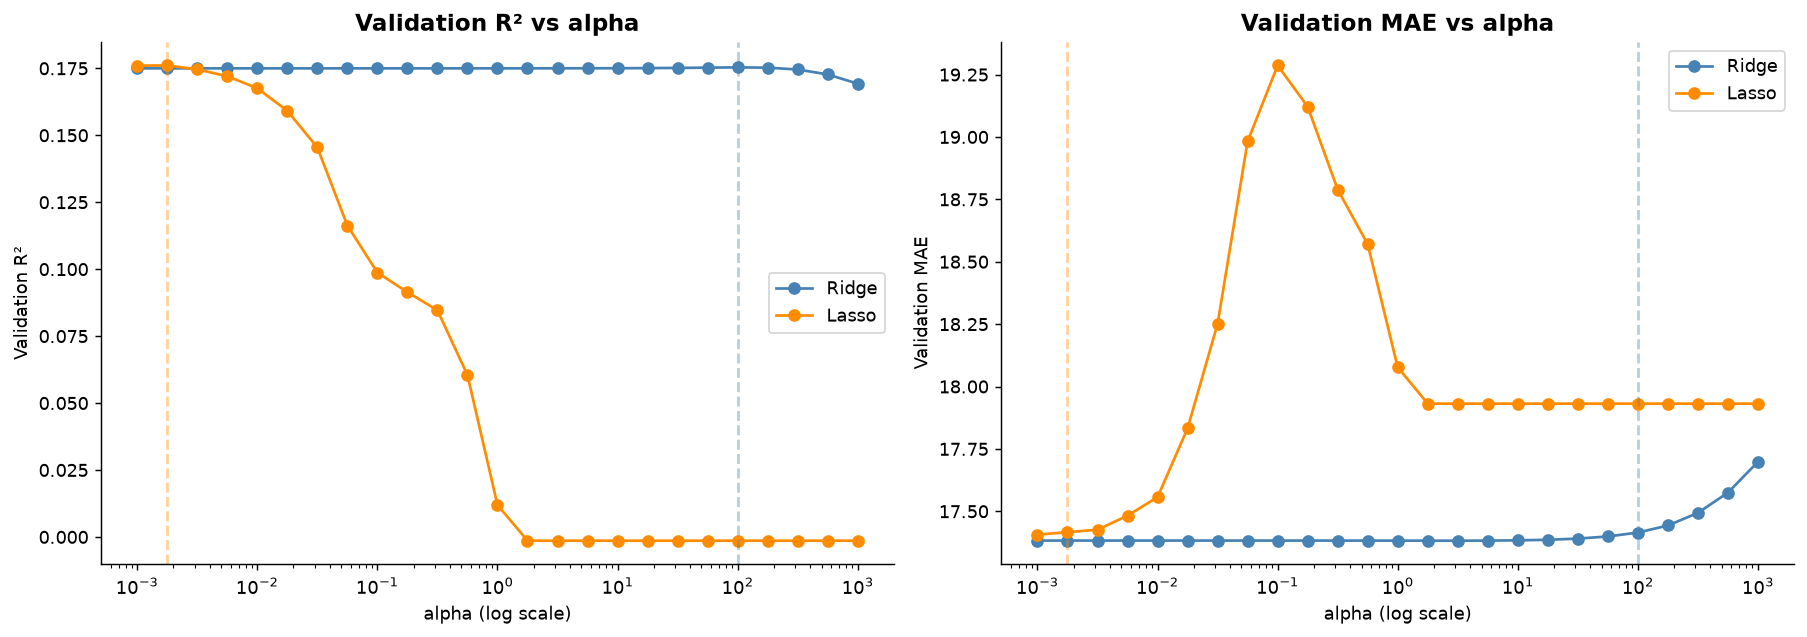

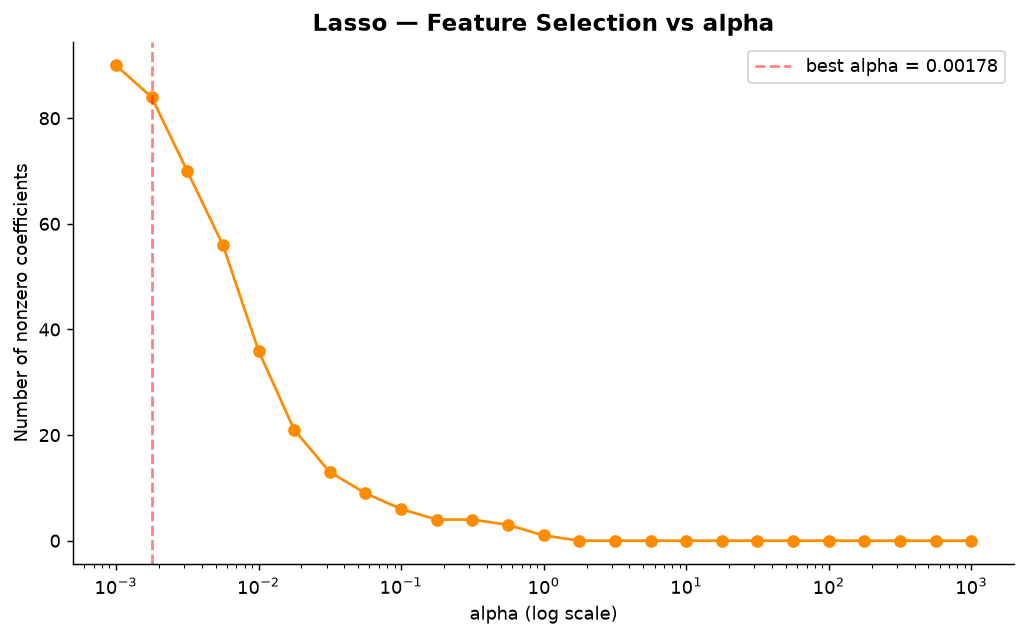

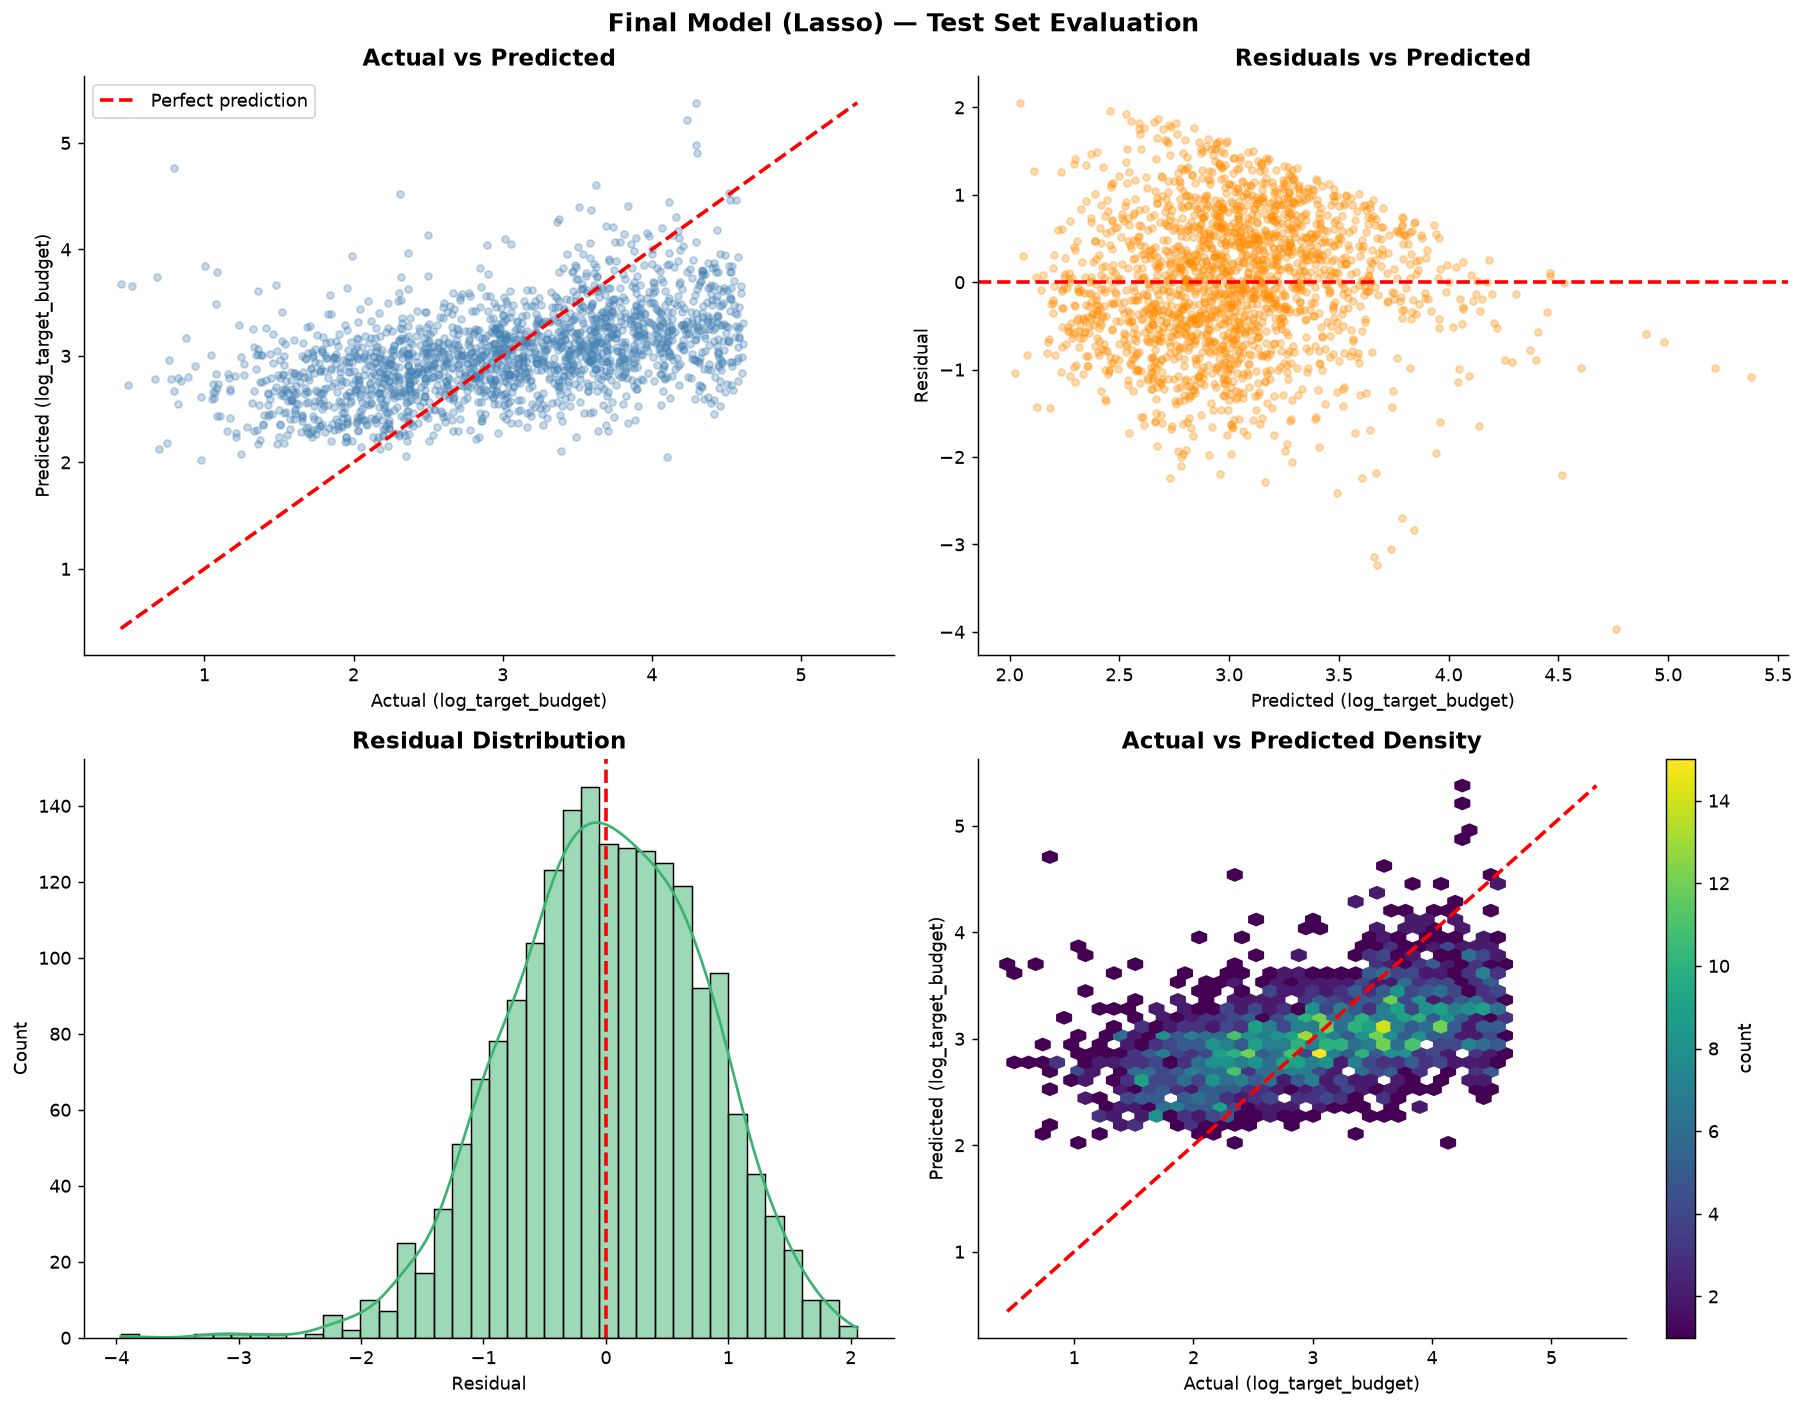

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1) Alpha sweep — R² and MAE vs alpha (Ridge + Lasso)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for results_df, label, color in [
    (ridge_results, "Ridge", "steelblue"),
    (lasso_results, "Lasso", "darkorange"),
]:
    sorted_by_alpha = results_df.sort_values("alpha")

    axes[0].plot(
        sorted_by_alpha["alpha"], sorted_by_alpha["r2_val"],
        marker="o", label=label, color=color,
    )
    axes[1].plot(
        sorted_by_alpha["alpha"], sorted_by_alpha["mae_val"],
        marker="o", label=label, color=color,
    )

axes[0].set_xscale("log")
axes[0].set_xlabel("alpha (log scale)")
axes[0].set_ylabel("Validation R²")
axes[0].set_title("Validation R² vs alpha")
axes[0].legend()
axes[0].axvline(best_ridge_alpha, color="steelblue", linestyle="--", alpha=0.4)
axes[0].axvline(best_lasso_alpha, color="darkorange", linestyle="--", alpha=0.4)

axes[1].set_xscale("log")
axes[1].set_xlabel("alpha (log scale)")
axes[1].set_ylabel("Validation MAE")
axes[1].set_title("Validation MAE vs alpha")
axes[1].legend()
axes[1].axvline(best_ridge_alpha, color="steelblue", linestyle="--", alpha=0.4)
axes[1].axvline(best_lasso_alpha, color="darkorange", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# ============================================================
# 2) Lasso — number of nonzero coefficients vs alpha
#    (shows feature selection behavior — useful given 164 cols)
# ============================================================

lasso_sorted = lasso_results.sort_values("alpha")

plt.figure(figsize=(8, 5))
plt.plot(lasso_sorted["alpha"], lasso_sorted["n_nonzero_coefs"], marker="o", color="darkorange")
plt.axvline(best_lasso_alpha, color="red", linestyle="--", alpha=0.5, label=f"best alpha = {best_lasso_alpha:.5f}")
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("Number of nonzero coefficients")
plt.title("Lasso — Feature Selection vs alpha")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 3) Final model diagnostics on TEST set
# ============================================================

residuals_te = yB_te - pred_te

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle(f"Final Model ({final_name}) — Test Set Evaluation", fontsize=14, fontweight="bold")

# Actual vs Predicted
ax = axes[0, 0]
ax.scatter(yB_te, pred_te, alpha=0.3, s=15, color="steelblue")
lims = [min(yB_te.min(), pred_te.min()), max(yB_te.max(), pred_te.max())]
ax.plot(lims, lims, "r--", lw=2, label="Perfect prediction")
ax.set_xlabel("Actual (log_target_budget)")
ax.set_ylabel("Predicted (log_target_budget)")
ax.set_title("Actual vs Predicted")
ax.legend()

# Residuals vs Predicted
ax = axes[0, 1]
ax.scatter(pred_te, residuals_te, alpha=0.3, s=15, color="darkorange")
ax.axhline(0, color="red", linestyle="--", lw=2)
ax.set_xlabel("Predicted (log_target_budget)")
ax.set_ylabel("Residual")
ax.set_title("Residuals vs Predicted")

# Residual distribution
ax = axes[1, 0]
sns.histplot(residuals_te, bins=40, kde=True, ax=ax, color="mediumseagreen")
ax.axvline(0, color="red", linestyle="--", lw=2)
ax.set_xlabel("Residual")
ax.set_title("Residual Distribution")

# Density heatmap
ax = axes[1, 1]
hb = ax.hexbin(yB_te, pred_te, gridsize=35, cmap="viridis", mincnt=1)
ax.plot(lims, lims, "r--", lw=2)
ax.set_xlabel("Actual (log_target_budget)")
ax.set_ylabel("Predicted (log_target_budget)")
ax.set_title("Actual vs Predicted Density")
fig.colorbar(hb, ax=ax, label="count")

plt.tight_layout()
plt.show()

## PCA plotting

PC1 explains 5.79% of variance
PC2 explains 4.84% of variance
Combined: 10.63%


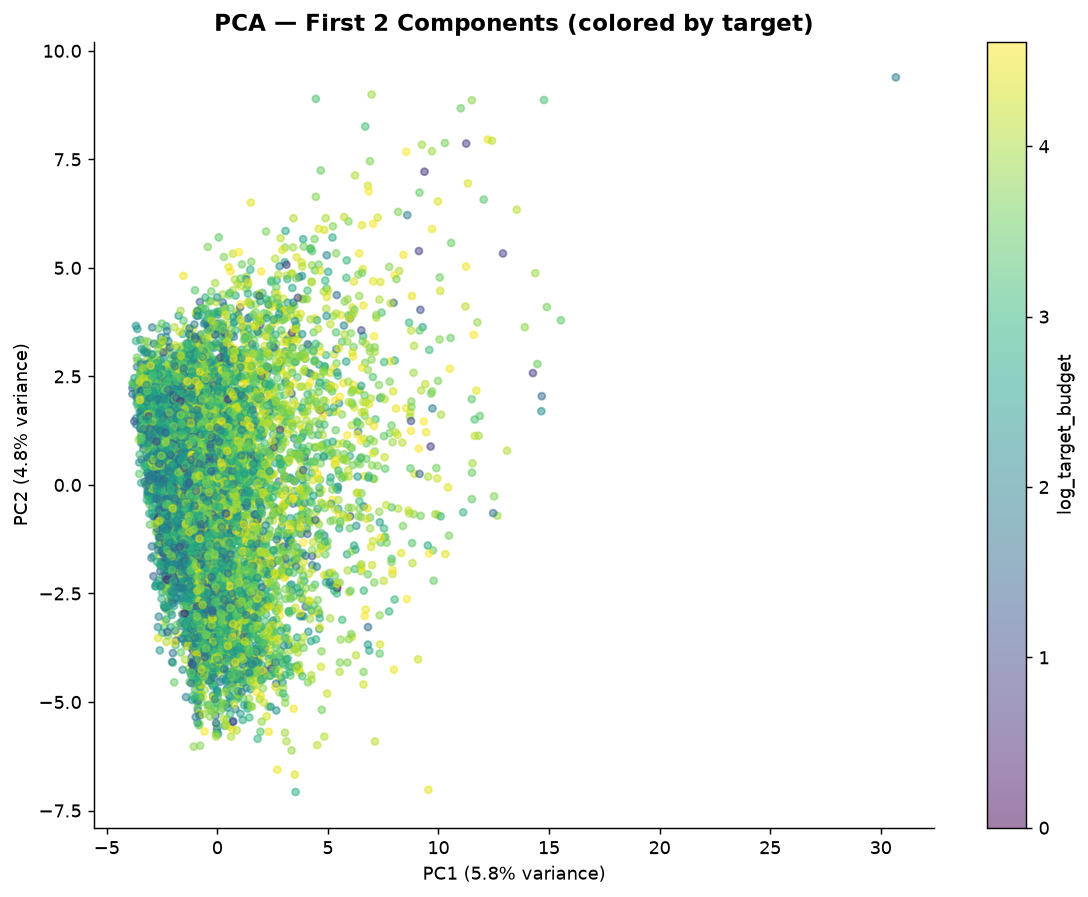

In [29]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ============================================================
# PCA on training features
# ============================================================

# Standardize first — PCA is scale-sensitive and your features
# mix one-hot columns with raw-scale numeric ones
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_tr)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(f"PC1 explains {explained[0]:.2%} of variance")
print(f"PC2 explains {explained[1]:.2%} of variance")
print(f"Combined: {explained.sum():.2%}")

# --------------------------------------------------------
# Plot — colored by target (log_target_budget)
# --------------------------------------------------------

plt.figure(figsize=(9, 7))
sc = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=yB_tr,
    cmap="viridis",
    alpha=0.5,
    s=15,
)
plt.colorbar(sc, label="log_target_budget")
plt.xlabel(f"PC1 ({explained[0]:.1%} variance)")
plt.ylabel(f"PC2 ({explained[1]:.1%} variance)")
plt.title("PCA — First 2 Components (colored by target)")
plt.tight_layout()
plt.show()

## Cat Boost With Validation

In [32]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import itertools

# ============================================================
# Train + Evaluate CatBoost (fixed to use passed-in val set)
# ============================================================

def evaluate_catboost(
    X_tr, y_tr,
    X_val, y_val,
    X_te, y_te,
    name,
    weight_mode="sqrt",
    depth=6,
    l2_leaf_reg=10,
    learning_rate=0.02,
    bagging_temperature=1,
    verbose=0,
):
    budget_train = np.expm1(y_tr)

    if weight_mode == "none":
        sample_weight = None
    elif weight_mode == "log":
        sample_weight = np.log1p(budget_train)
    elif weight_mode == "sqrt":
        sample_weight = np.sqrt(budget_train + 1)
    elif weight_mode == "linear":
        sample_weight = budget_train
    else:
        raise ValueError("Unknown weight mode")

    if sample_weight is not None:
        sample_weight = sample_weight / sample_weight.mean()

    model = CatBoostRegressor(
        iterations=5000,
        learning_rate=learning_rate,
        depth=depth,
        l2_leaf_reg=l2_leaf_reg,
        bootstrap_type="Bayesian",
        bagging_temperature=bagging_temperature,
        loss_function="RMSE",
        eval_metric="RMSE",
        random_seed=42,
        early_stopping_rounds=200,
        verbose=verbose,
    )

    model.fit(
        X_tr, y_tr,
        sample_weight=sample_weight,
        eval_set=(X_val, y_val),
        use_best_model=True,
    )

    pred_tr = model.predict(X_tr)
    pred_val = model.predict(X_val)
    pred_te = model.predict(X_te)

    r2_tr = r2_score(y_tr, pred_tr)
    r2_val = r2_score(y_val, pred_val)
    r2_te = r2_score(y_te, pred_te)

    mae_val = mean_absolute_error(np.expm1(y_val), np.expm1(pred_val))
    mae_te = mean_absolute_error(np.expm1(y_te), np.expm1(pred_te))
    rmse_te = np.sqrt(mean_squared_error(y_te, pred_te))

    return {
        "model": model,
        "best_iteration": model.get_best_iteration(),
        "pred_val": pred_val,
        "pred_test": pred_te,
        "r2_train": r2_tr,
        "r2_val": r2_val,
        "r2_test": r2_te,
        "mae_val": mae_val,
        "mae_test": mae_te,
        "rmse_test": rmse_te,
    }


# ============================================================
# Hyperparameter grid search — evaluated on VALIDATION
# ============================================================

def tune_catboost(
    X_tr, y_tr,
    X_val, y_val,
    weight_mode="none",
    depths=(4, 6, 8 , 10 , 12 , 16),
    l2_leaf_regs=(3, 10, 30 , 60),
    learning_rates=(0.01 , 0.02, 0.03 , 0.05 , 0.1),
    bagging_temperatures=(0,1 , 0.5, 1, 2 , 3),
):
    grid = list(itertools.product(depths, l2_leaf_regs, learning_rates, bagging_temperatures))
    print(f"Sweeping {len(grid)} combinations...")

    results = []

    for i, (depth, l2, lr, bt) in enumerate(grid, 1):
        res = evaluate_catboost(
            X_tr, y_tr,
            X_val, y_val,
            X_val, y_val,   # test slot unused here — just reusing val for the call
            name=f"combo_{i}",
            weight_mode=weight_mode,
            depth=depth,
            l2_leaf_reg=l2,
            learning_rate=lr,
            bagging_temperature=bt,
            verbose=0,
        )

        results.append({
            "depth": depth,
            "l2_leaf_reg": l2,
            "learning_rate": lr,
            "bagging_temperature": bt,
            "best_iteration": res["best_iteration"],
            "r2_val": res["r2_val"],
            "mae_val": res["mae_val"],
        })

        print(f"[{i}/{len(grid)}] depth={depth} l2={l2} lr={lr} bt={bt} "
              f"-> val R²={res['r2_val']:.4f}, val MAE={res['mae_val']:,.0f}")

    results_df = pd.DataFrame(results).sort_values("r2_val", ascending=False).reset_index(drop=True)

    print(f"\n{'='*70}")
    print("Top 10 combinations by validation R²")
    print(f"{'='*70}")
    print(results_df.head(10).to_string(index=False))

    best = results_df.iloc[0]
    print(f"\nBest params: depth={best['depth']}, l2_leaf_reg={best['l2_leaf_reg']}, "
          f"learning_rate={best['learning_rate']}, bagging_temperature={best['bagging_temperature']}")
    print(f"Best val R²: {best['r2_val']:.4f}")

    return results_df, best


# ============================================================
# Run sweep
# ============================================================

cat_results, best_cat_params = tune_catboost(
    X_tr, yB_tr,
    X_val, yB_val,
    weight_mode="none",
)

Sweeping 720 combinations...
[1/720] depth=4 l2=3 lr=0.01 bt=0 -> val R²=0.3325, val MAE=14
[2/720] depth=4 l2=3 lr=0.01 bt=1 -> val R²=0.3347, val MAE=14
[3/720] depth=4 l2=3 lr=0.01 bt=0.5 -> val R²=0.3333, val MAE=14
[4/720] depth=4 l2=3 lr=0.01 bt=1 -> val R²=0.3347, val MAE=14
[5/720] depth=4 l2=3 lr=0.01 bt=2 -> val R²=0.3353, val MAE=14
[6/720] depth=4 l2=3 lr=0.01 bt=3 -> val R²=0.3365, val MAE=14
[7/720] depth=4 l2=3 lr=0.02 bt=0 -> val R²=0.3336, val MAE=14
[8/720] depth=4 l2=3 lr=0.02 bt=1 -> val R²=0.3353, val MAE=14
[9/720] depth=4 l2=3 lr=0.02 bt=0.5 -> val R²=0.3348, val MAE=14
[10/720] depth=4 l2=3 lr=0.02 bt=1 -> val R²=0.3353, val MAE=14
[11/720] depth=4 l2=3 lr=0.02 bt=2 -> val R²=0.3353, val MAE=14
[12/720] depth=4 l2=3 lr=0.02 bt=3 -> val R²=0.3356, val MAE=14
[13/720] depth=4 l2=3 lr=0.03 bt=0 -> val R²=0.3353, val MAE=14
[14/720] depth=4 l2=3 lr=0.03 bt=1 -> val R²=0.3359, val MAE=14
[15/720] depth=4 l2=3 lr=0.03 bt=0.5 -> val R²=0.3365, val MAE=14
[16/720] depth

CatBoostError: bad allocation

Sweeping 720 combinations...
[1/720] depth=4 l2=3 lr=0.01 bt=0 -> val R²=0.3325, val MAE=14


KeyboardInterrupt: 

In [34]:
# ============================================================
# Final CatBoost — best params, evaluated on TEST once
# ============================================================

cat_final = evaluate_catboost(
    X_tr, yB_tr,
    X_val, yB_val,
    X_te, yB_te,
    name="CatBoost_Final",
    weight_mode="none",
    depth=int(best_cat_params["depth"]),
    l2_leaf_reg=best_cat_params["l2_leaf_reg"],
    learning_rate=best_cat_params["learning_rate"],
    bagging_temperature=best_cat_params["bagging_temperature"],
    verbose=100,
)

print(f"\nFinal Test R²  : {cat_final['r2_test']:.4f}")
print(f"Final Test MAE : {cat_final['mae_test']:,.0f}")
print(f"Final Test RMSE: {cat_final['rmse_test']:.4f}")

0:	learn: 0.8838676	test: 0.8996661	best: 0.8996661 (0)	total: 7.35ms	remaining: 36.7s
100:	learn: 0.7187769	test: 0.7499530	best: 0.7499530 (100)	total: 596ms	remaining: 28.9s
200:	learn: 0.7003475	test: 0.7447244	best: 0.7447244 (200)	total: 1.33s	remaining: 31.8s
300:	learn: 0.6846314	test: 0.7414626	best: 0.7414626 (300)	total: 2.27s	remaining: 35.4s
400:	learn: 0.6709101	test: 0.7401565	best: 0.7401389 (396)	total: 2.9s	remaining: 33.3s
500:	learn: 0.6579948	test: 0.7394289	best: 0.7393392 (458)	total: 3.63s	remaining: 32.6s
600:	learn: 0.6463282	test: 0.7393084	best: 0.7391987 (593)	total: 4.33s	remaining: 31.7s
700:	learn: 0.6360468	test: 0.7388723	best: 0.7386483 (678)	total: 4.95s	remaining: 30.3s
800:	learn: 0.6256180	test: 0.7390174	best: 0.7386483 (678)	total: 5.59s	remaining: 29.3s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.7386483038
bestIteration = 678

Shrink model to first 679 iterations.

Final Test R²  : 0.3448
Final Test MAE : 15
Final Test

## 5 · Train CatBoost model

In [17]:
from catboost import CatBoostRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

import numpy as np

# ============================================================
# Train + Evaluate CatBoost
# ============================================================

def evaluate_catboost(
    X_tr,
    y_tr,
    X_te,
    y_te,
    name,
    weight_mode="sqrt",   # none | log | sqrt | linear
):

    # --------------------------------------------------------
    # Sample weights
    # --------------------------------------------------------

    budget_train = np.expm1(y_tr)

    if weight_mode == "none":
        sample_weight = None

    elif weight_mode == "log":
        sample_weight = np.log1p(budget_train)

    elif weight_mode == "sqrt":
        sample_weight = np.sqrt(budget_train + 1)

    elif weight_mode == "linear":
        sample_weight = budget_train

    else:
        raise ValueError("Unknown weight mode")

    if sample_weight is not None:
        sample_weight = sample_weight / sample_weight.mean()

    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    model = CatBoostRegressor(

        iterations=5000,
        learning_rate=0.02,
        depth=6,

        l2_leaf_reg=10,

        bootstrap_type="Bayesian",
        bagging_temperature=1,

        loss_function="RMSE",
        eval_metric="RMSE",

        random_seed=42,

        early_stopping_rounds=200,

        verbose=100,
    )

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    model.fit(

        X_tr,
        y_tr,

        sample_weight=sample_weight,

        eval_set=(X_val, yB_val),

        use_best_model=True,

    )

    # --------------------------------------------------------
    # Predict
    # --------------------------------------------------------

    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    mae_te = mean_absolute_error(
        np.expm1(y_te),
        np.expm1(pred_te),
    )

    rmse_te = np.sqrt(
        mean_squared_error(
            y_te,
            pred_te,
        )
    )

    r2_tr = r2_score(y_tr, pred_tr)
    r2_te = r2_score(y_te, pred_te)

    print()
    print("=" * 70)
    print(name)
    print("=" * 70)
    print(f"Weight mode    : {weight_mode}")
    print(f"Best iteration : {model.get_best_iteration()}")
    print(f"Train R²       : {r2_tr:.4f}")
    print(f"Test  R²       : {r2_te:.4f}")
    print(f"RMSE (log)     : {rmse_te:.4f}")
    print(f"MAE            : {mae_te:,.0f}")

    cov10 = interval_accuracy(y_te, pred_te, 0.10)
    cov20 = interval_accuracy(y_te, pred_te, 0.20)
    cov30 = interval_accuracy(y_te, pred_te, 0.30)
    cov50 = interval_accuracy(y_te, pred_te, 0.50)

    print(f"Coverage ±10% : {cov10:.2%}")
    print(f"Coverage ±20% : {cov20:.2%}")
    print(f"Coverage ±30% : {cov30:.2%}")
    print(f"Coverage ±50% : {cov50:.2%}")

    return {
        "model": model,
        "history": None,
        "pred_test": pred_te,
        "r2_train": r2_tr,
        "r2_test": r2_te,
        "mae_test": mae_te,
    }


# ============================================================
# Train
# ============================================================

cat_none = evaluate_catboost(
    X_tr,
    yB_tr,
    X_te,
    yB_te,
    "CatBoost_None",
    weight_mode="none",
)


0:	learn: 1.3464249	test: 1.3487450	best: 1.3487450 (0)	total: 6.34ms	remaining: 31.7s
100:	learn: 0.9472961	test: 0.9477763	best: 0.9477763 (100)	total: 494ms	remaining: 23.9s
200:	learn: 0.9145214	test: 0.9191874	best: 0.9191874 (200)	total: 1.11s	remaining: 26.6s
300:	learn: 0.9040203	test: 0.9129837	best: 0.9129837 (300)	total: 1.67s	remaining: 26.1s
400:	learn: 0.8964431	test: 0.9088910	best: 0.9088910 (400)	total: 2.21s	remaining: 25.4s
500:	learn: 0.8898812	test: 0.9055290	best: 0.9055124 (499)	total: 2.66s	remaining: 23.9s
600:	learn: 0.8813518	test: 0.9015623	best: 0.9015623 (600)	total: 3.17s	remaining: 23.2s
700:	learn: 0.8750548	test: 0.8989567	best: 0.8989567 (700)	total: 3.73s	remaining: 22.9s
800:	learn: 0.8696254	test: 0.8968290	best: 0.8968271 (798)	total: 4.27s	remaining: 22.4s
900:	learn: 0.8636665	test: 0.8948827	best: 0.8948827 (900)	total: 4.84s	remaining: 22s
1000:	learn: 0.8585222	test: 0.8927880	best: 0.8927880 (1000)	total: 5.36s	remaining: 21.4s
1100:	learn: 

## Save Model

In [ ]:
model = cat_none["model"]


# Save the trained model itself
model.save_model("catboost_price_model.cbm")

project_type_dummy_cols = [c for c in ALL_FEATURES if c.startswith("project_type_")]

feature_schema = {
    "columns": ALL_FEATURES,                      # exact order model was trained on
    "target_transform": "log1p",
    "ordinal_cols": ordinal_cols_present,          # which ordinal cols actually survived NON_FEATURE
    "enum_order": {c: ENUM_ORDER[c] for c in ordinal_cols_present},  # index = encoded value
    "project_type_prefix": "project_type_",
    "project_type_dummy_cols": project_type_dummy_cols,  # exact categories seen in training data
}
with open("catboost_price_model_schema.json", "w", encoding="utf-8") as f:
    json.dump(feature_schema, f, ensure_ascii=False, indent=2)

print(f"Saved model with {len(ALL_FEATURES)} features")
print(f"Ordinal cols in this model: {ordinal_cols_present}")
print(f"project_type dummies in this model: {project_type_dummy_cols}")



## 6 · Deep learning approach (feed-forward neural net)
Same features, same log-transformed targets — but a small dense neural network instead of trees. Neural nets need scaled inputs (trees don't), so we standardize features first.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np

# ============================================================
# Scale features
# ============================================================
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_te_scaled = scaler.transform(X_te)

print(X_tr_scaled.shape)
print(X_te_scaled.shape)

# ============================================================
# Build model
# ============================================================
def build_mlp(input_dim, name):
    l2 = regularizers.l2(1e-5)  # mild — drop this first if train R² stays low

    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(256, activation="gelu", kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.Dropout(0.25),

        layers.Dense(128, activation="gelu", kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.Dropout(0.15),

        layers.Dense(64, activation="gelu", kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.Dropout(0.10),

        layers.Dense(32, activation="gelu", kernel_regularizer=l2),
        layers.Dense(1),
    ], name=name)

    optimizer = keras.optimizers.AdamW(learning_rate=3e-4, weight_decay=1e-4)

    model.compile(
        optimizer=optimizer,
        loss=keras.losses.Huber(delta=1.0),  # keep 1.0 for now; try 0.5 as a separate run if outliers are a known issue
        metrics=["mae", keras.metrics.RootMeanSquaredError(name="rmse")],
    )
    return model

# ============================================================
# Callbacks
# ============================================================
early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=25, restore_best_weights=True,
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=10, min_lr=1e-6, verbose=1,
)

# ============================================================
# Train + Evaluate
# ============================================================
def evaluate_dl(X_tr_s, y_tr, X_te_s, y_te, name, epochs=300, batch_size=64):
    model = build_mlp(X_tr_s.shape[1], name)

    history = model.fit(
        X_tr_s, y_tr,
        validation_split=0.15,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop, reduce_lr],
        verbose=1,          # <-- per-epoch progress bar
        shuffle=True,
    )

    pred_tr = model.predict(X_tr_s, verbose=0).flatten()
    pred_te = model.predict(X_te_s, verbose=0).flatten()

    mae_te  = mean_absolute_error(np.expm1(y_te), np.expm1(pred_te))
    rmse_te = np.sqrt(mean_squared_error(y_te, pred_te))
    r2_tr   = r2_score(y_tr, pred_tr)
    r2_te   = r2_score(y_te, pred_te)
    n_epochs = len(history.history["loss"])

    print()
    print("=" * 70)
    print(name)
    print("=" * 70)
    print(f"Training epochs : {n_epochs}")
    print(f"Train R²        : {r2_tr:.4f}")
    print(f"Test  R²        : {r2_te:.4f}")
    print(f"RMSE (log)      : {rmse_te:.4f}")
    print(f"MAE             : {mae_te:,.0f}")

    cov10 = interval_accuracy(y_te, pred_te, 0.10)
    cov20 = interval_accuracy(y_te, pred_te, 0.20)
    cov30 = interval_accuracy(y_te, pred_te, 0.30)
    cov50 = interval_accuracy(y_te, pred_te, 0.50)

    print(f"Coverage ±10% : {cov10:.2%}")
    print(f"Coverage ±20% : {cov20:.2%}")
    print(f"Coverage ±30% : {cov30:.2%}")
    print(f"Coverage ±50% : {cov50:.2%}")

    return {
        "model": model, "history": history, "pred_test": pred_te,
        "r2_train": r2_tr, "r2_test": r2_te, "mae_test": mae_te,
    }

# ============================================================
# Train
# ============================================================
print("=== Deep Learning Budget Model ===")

dl_budget = evaluate_dl(
    X_tr_scaled, yB_tr, X_te_scaled, yB_te, "MLP_AdamW_Huber",
)

(8883, 107)
(3808, 107)
=== Deep Learning Budget Model ===
Epoch 1/300
118/118 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 1.2619 - mae: 1.7010 - rmse: 2.0513 - val_loss: 0.8853 - val_mae: 1.3134 - val_rmse: 1.5633 - learning_rate: 3.0000e-04
Epoch 2/300
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4908 - mae: 0.8680 - rmse: 1.0907 - val_loss: 0.3726 - val_mae: 0.7359 - val_rmse: 0.9093 - learning_rate: 3.0000e-04
Epoch 3/300
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4064 - mae: 0.7746 - rmse: 0.9649 - val_loss: 0.3339 - val_mae: 0.6850 - val_rmse: 0.8560 - learning_rate: 3.0000e-04
Epoch 4/300
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3704 - mae: 0.7291 - rmse: 0.9142 - val_loss: 0.3277 - val_mae: 0.6783 - val_rmse: 0.8508 - learning_rate: 3.0000e-04
Epoch 5/300
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3473 - mae: 0.7006 - rmse: 0.8781 - val_loss: 0.3169 - val_mae: 0.6654 - val_rmse: 0.8330 - learning_rate: 3.0000e-04
Epoch 6/300
118/118 ━━━━━━━━━━━━━━━━

## 7a Training Curve

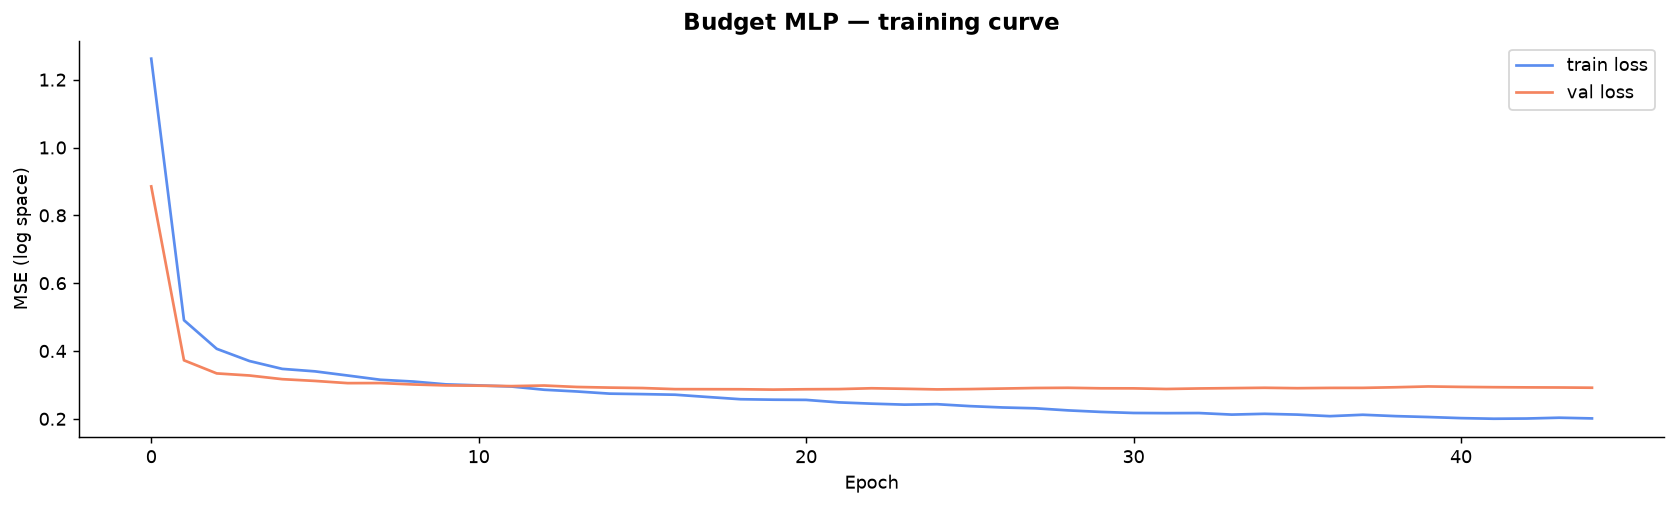

In [ ]:
# Training curves — loss over epochs, useful for spotting over/underfitting
fig, axes = plt.subplots(1, 1, figsize=(13, 4))
for ax, res, title in [
    (axes, dl_budget,   'Budget MLP — training curve'),
]:
    h = res['history'].history
    ax.plot(h['loss'], label='train loss', color=ACCENT)
    ax.plot(h['val_loss'], label='val loss', color=ACCENT2)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE (log space)')
    ax.legend()
plt.tight_layout(); plt.show()


## 7b top projects with max and min errors

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Actual vs Predicted comparison table
# ============================================================

actual_usd    = np.expm1(yB_te)
predicted_usd = np.expm1(dl_budget['pred_test'])

comparison = pd.DataFrame({
    'project_id': df.loc[X_te.index, 'project_id'].values,   # adjust `df` to whatever your source frame is named
    'actual': actual_usd,
    'predicted': predicted_usd,
}, index=X_te.index)

comparison['abs_error']   = (comparison['actual'] - comparison['predicted']).abs()
comparison['pct_error']   = comparison['abs_error'] / comparison['actual'] * 100

comparison_sorted_worst = comparison.sort_values('pct_error', ascending=False)
comparison_sorted_best  = comparison.sort_values('pct_error', ascending=True)

print("=== Worst 15 predictions (highest % error) ===")
print(comparison_sorted_worst.head(15).round(2).to_string())

print()
print("=== Best 15 predictions (lowest % error) ===")
print(comparison_sorted_best.head(15).round(2).to_string())

print()
print(f"Median % error : {comparison['pct_error'].median():.2f}%")
print(f"Mean % error   : {comparison['pct_error'].mean():.2f}%")

# ============================================================
# Actual vs Predicted scatter chart with error-band lines
# ============================================================

# fig, ax = plt.subplots(figsize=(8, 8))

# ax.scatter(comparison['predicted'], comparison['actual'],
#            alpha=0.4, s=20, color='steelblue', label='Predictions')

# lims = [0, max(comparison['actual'].max(), comparison['predicted'].max()) * 1.05]
# x_line = np.linspace(lims[0], lims[1], 200)

# # actual = predicted (perfect prediction line)
# ax.plot(x_line, x_line, color='black', linewidth=1.5, label='Actual = Predicted')

# # tolerance bands: actual within ±p% of predicted
# for pct, color in [(0.10, 'green'), (0.20, 'orange'), (0.50, 'red')]:
#     ax.plot(x_line, x_line * (1 + pct), color=color, linestyle='--', linewidth=1,
#              label=f'±{int(pct*100)}%')
#     ax.plot(x_line, x_line * (1 - pct), color=color, linestyle='--', linewidth=1)

# ax.set_xlim(lims)
# ax.set_ylim(lims)
# ax.set_xlabel('Predicted Price ($)')
# ax.set_ylabel('Actual Price ($)')
# ax.set_title('Actual vs Predicted Price')
# ax.legend(loc='upper left')
# ax.set_aspect('equal', adjustable='box')

# plt.tight_layout()
# plt.show()

=== Worst 15 predictions (highest % error) ===
                                project_id  actual  predicted  abs_error  pct_error
2716  9d194fc6-84a1-4ff5-9f57-0e694e26e6b2    0.68  58.590000      57.91    8548.09
658   232ca616-0e3b-4d8e-9446-7f459f446133    0.55  42.709999      42.16    7652.99
2702  89cc0e42-2cef-4b1a-a7ca-87f781b92292    1.30  41.380001      40.09    3089.35
3423  c50981db-5fbe-442b-b43d-ff7384035085    1.73  55.070000      53.34    3085.47
2695  84838520-b318-49aa-84d9-59cbea10a596    1.39  43.230000      41.84    3007.15
2099  8a5033f0-d536-4ffd-8577-054e82361dbe    0.98  28.540001      27.56    2824.70
235   ffb6e940-d9c7-4648-8a19-03dcdf6cc2a4    1.97  51.450001      49.49    2517.18
477   834ba26c-6160-4df9-a959-4d7382c7ee11    0.63  16.360001      15.73    2493.67
4398  1ffc56ff-a4e8-4d62-a960-18b14a380e4a    1.81  46.720001      44.91    2474.53
479   05d206de-a43b-45db-aa2a-7bbddac907dc    1.20  28.250000      27.05    2249.67
2691  958f3824-8611-4655-87a2

## 7c heat map of project prediction distribuition

Dropped 770 rows (20.2%) above $50


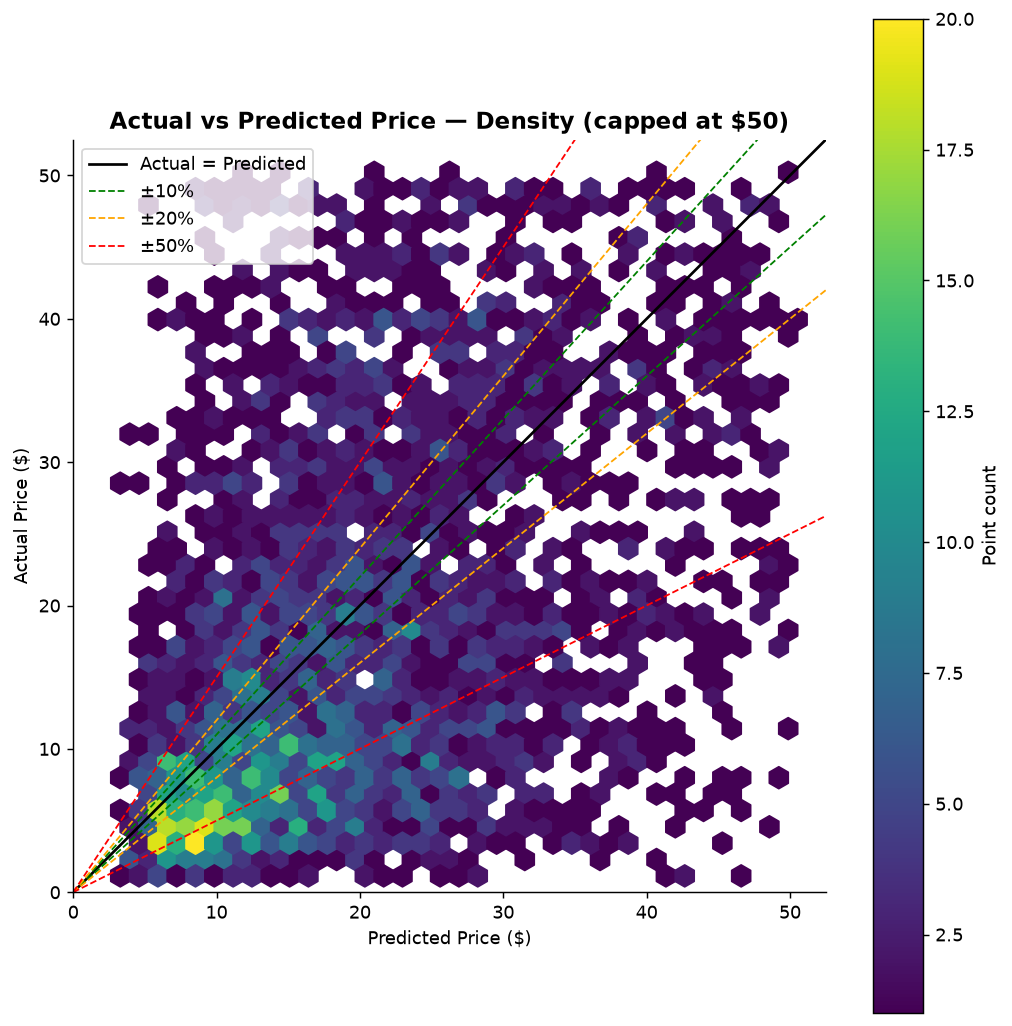

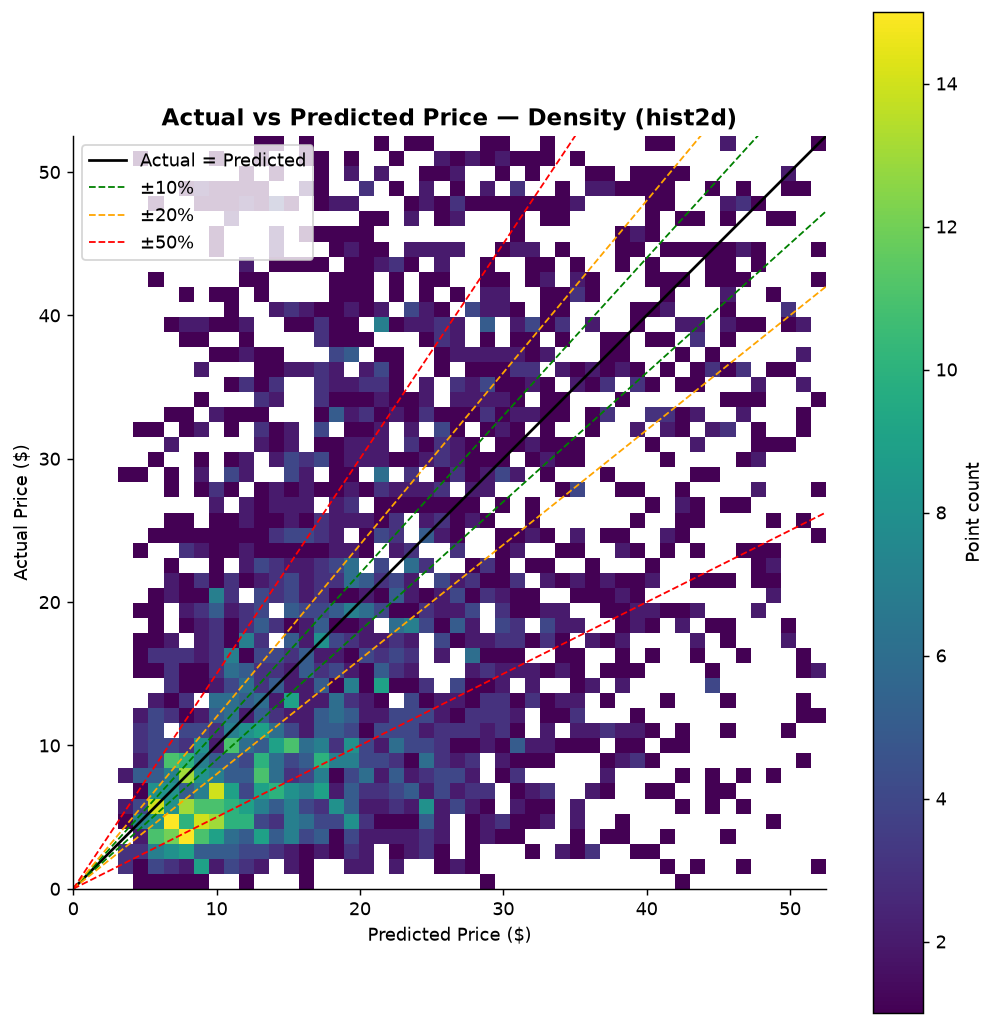

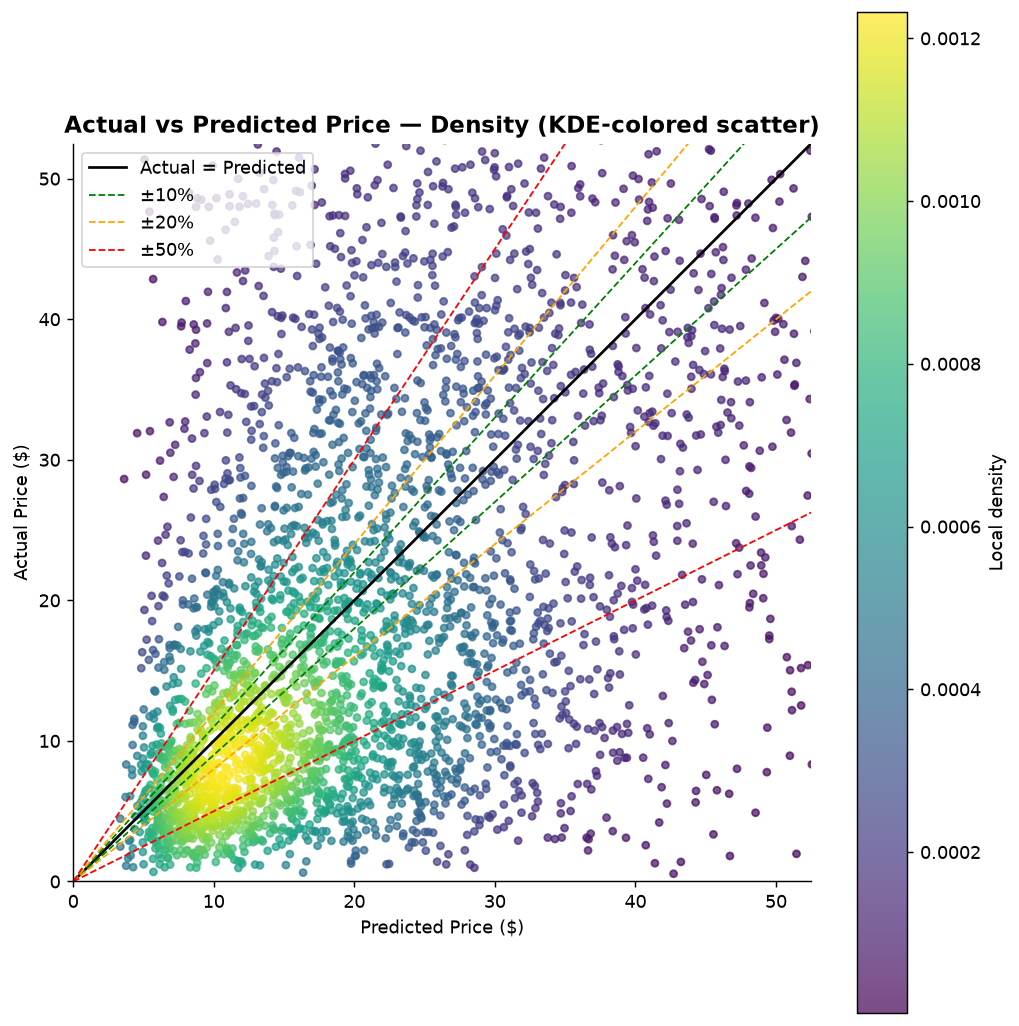

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde

# ============================================================
# Set your cap here
# ============================================================
MAX_PRICE = 50   # adjust this — try comparison['actual'].quantile(0.95) to auto-pick a reasonable cutoff

plot_data = comparison[
    (comparison['actual'] <= MAX_PRICE) &
    (comparison['predicted'] <= MAX_PRICE)
]

n_dropped = len(comparison) - len(plot_data)
print(f"Dropped {n_dropped} rows ({n_dropped/len(comparison):.1%}) above ${MAX_PRICE:,}")

lims = [0, MAX_PRICE * 1.05]
x_line = np.linspace(lims[0], lims[1], 200)

def draw_bands(ax):
    ax.plot(x_line, x_line, color='black', linewidth=1.5, label='Actual = Predicted')
    for pct, color in [(0.10, 'green'), (0.20, 'orange'), (0.50, 'red')]:
        ax.plot(x_line, x_line * (1 + pct), color=color, linestyle='--', linewidth=1,
                 label=f'±{int(pct*100)}%')
        ax.plot(x_line, x_line * (1 - pct), color=color, linestyle='--', linewidth=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('Predicted Price ($)')
    ax.set_ylabel('Actual Price ($)')
    ax.set_aspect('equal', adjustable='box')

# ------------------------------------------------------------
# hexbin, capped
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8))
hb = ax.hexbin(plot_data['predicted'], plot_data['actual'],
                gridsize=40, cmap='viridis', mincnt=1, extent=[*lims, *lims])
draw_bands(ax)
ax.set_title(f'Actual vs Predicted Price — Density (capped at ${MAX_PRICE:,})')
ax.legend(loc='upper left')
fig.colorbar(hb, ax=ax, label='Point count')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 8))
h = ax.hist2d(comparison['predicted'], comparison['actual'],
              bins=50, cmap='viridis', cmin=1, range=[lims, lims])
draw_bands(ax)
ax.set_title('Actual vs Predicted Price — Density (hist2d)')
ax.legend(loc='upper left')
fig.colorbar(h[3], ax=ax, label='Point count')
plt.tight_layout()
plt.show()


xy = np.vstack([comparison['predicted'], comparison['actual']])
density = gaussian_kde(xy)(xy)
order = density.argsort()  # plot densest points last so they're on top

fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(comparison['predicted'].values[order], comparison['actual'].values[order],
                 c=density[order], cmap='viridis', s=15, alpha=0.7)
draw_bands(ax)
ax.set_title('Actual vs Predicted Price — Density (KDE-colored scatter)')
ax.legend(loc='upper left')
fig.colorbar(sc, ax=ax, label='Local density')
plt.tight_layout()
plt.show()


## 7d Risedual plot

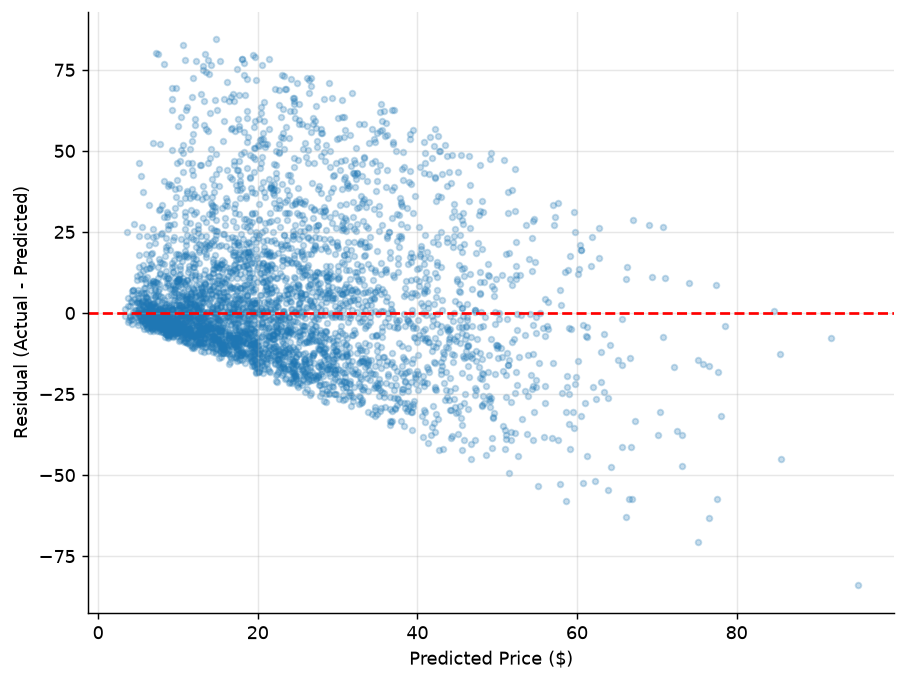

In [ ]:
actual = comparison['actual']
pred = comparison['predicted']
residual = actual - pred

mask = (
    (pred < 100) &
    (residual > -100) &
    (residual < 100)
)

plt.figure(figsize=(8,6))

plt.scatter(
    pred[mask],
    residual[mask],
    alpha=0.25,
    s=10
)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Price ($)")
plt.ylabel("Residual (Actual - Predicted)")
plt.grid(alpha=0.3)
plt.show()

## 7e Actual price vs Prediction error plot

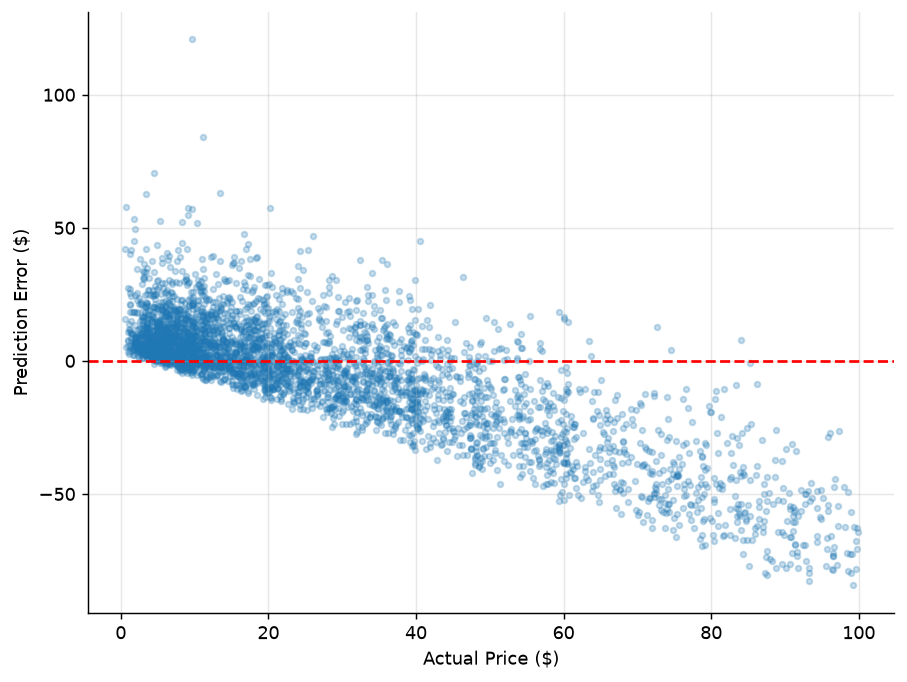

In [ ]:
error = pred - actual

mask = (
    (actual < 1000) &
    (error > -1000) &
    (error < 1000)
)

plt.figure(figsize=(8,6))

plt.scatter(
    actual[mask],
    error[mask],
    alpha=0.25,
    s=10
)

plt.axhline(0, color="red", ls="--")

plt.xlabel("Actual Price ($)")
plt.ylabel("Prediction Error ($)")
plt.grid(alpha=0.3)

plt.show()

## 7f Compare actual vs predicted prices properties

In [ ]:
bins = [0,10,20,30,40,50,75,100,np.inf]

df2 = pd.DataFrame({
    "actual": actual,
    "pred": pred,
})

df2["bin"] = pd.cut(df2["actual"], bins)

summary = df2.groupby("bin").agg(
    mean_actual=("actual", "mean"),
    mean_pred=("pred", "mean"),
)

# MAE
summary["mae"] = df2.groupby("bin").apply(
    lambda g: np.mean(np.abs(g["actual"] - g["pred"]))
)

# Mean Absolute Percentage Error (MAPE)
summary["mape"] = df2.groupby("bin").apply(
    lambda g: np.mean(
        np.abs(g["actual"] - g["pred"])
        / g["actual"].clip(lower=1)
    ) * 100
)

# Bias (positive = overpredict, negative = underpredict)
summary["bias"] = summary["mean_pred"] - summary["mean_actual"]

print(summary.round(2))



               mean_actual  mean_pred    mae    mape   bias
bin                                                        
(0.0, 10.0]           6.01  15.930000  10.22  237.30   9.93
(10.0, 20.0]         14.76  21.120001   9.20   65.35   6.35
(20.0, 30.0]         24.46  23.860001   9.64   39.57  -0.59
(30.0, 40.0]         35.03  28.910000  12.51   35.67  -6.12
(40.0, 50.0]         44.97  29.520000  17.68   39.15 -15.45
(50.0, 75.0]         61.27  32.200001  30.11   48.47 -29.07
(75.0, 100.0]        86.13  33.759998  52.43   60.60 -52.37


## 7g projects error sorted by error amount 

Clipped 1 rows (0.0%) beyond ±$100


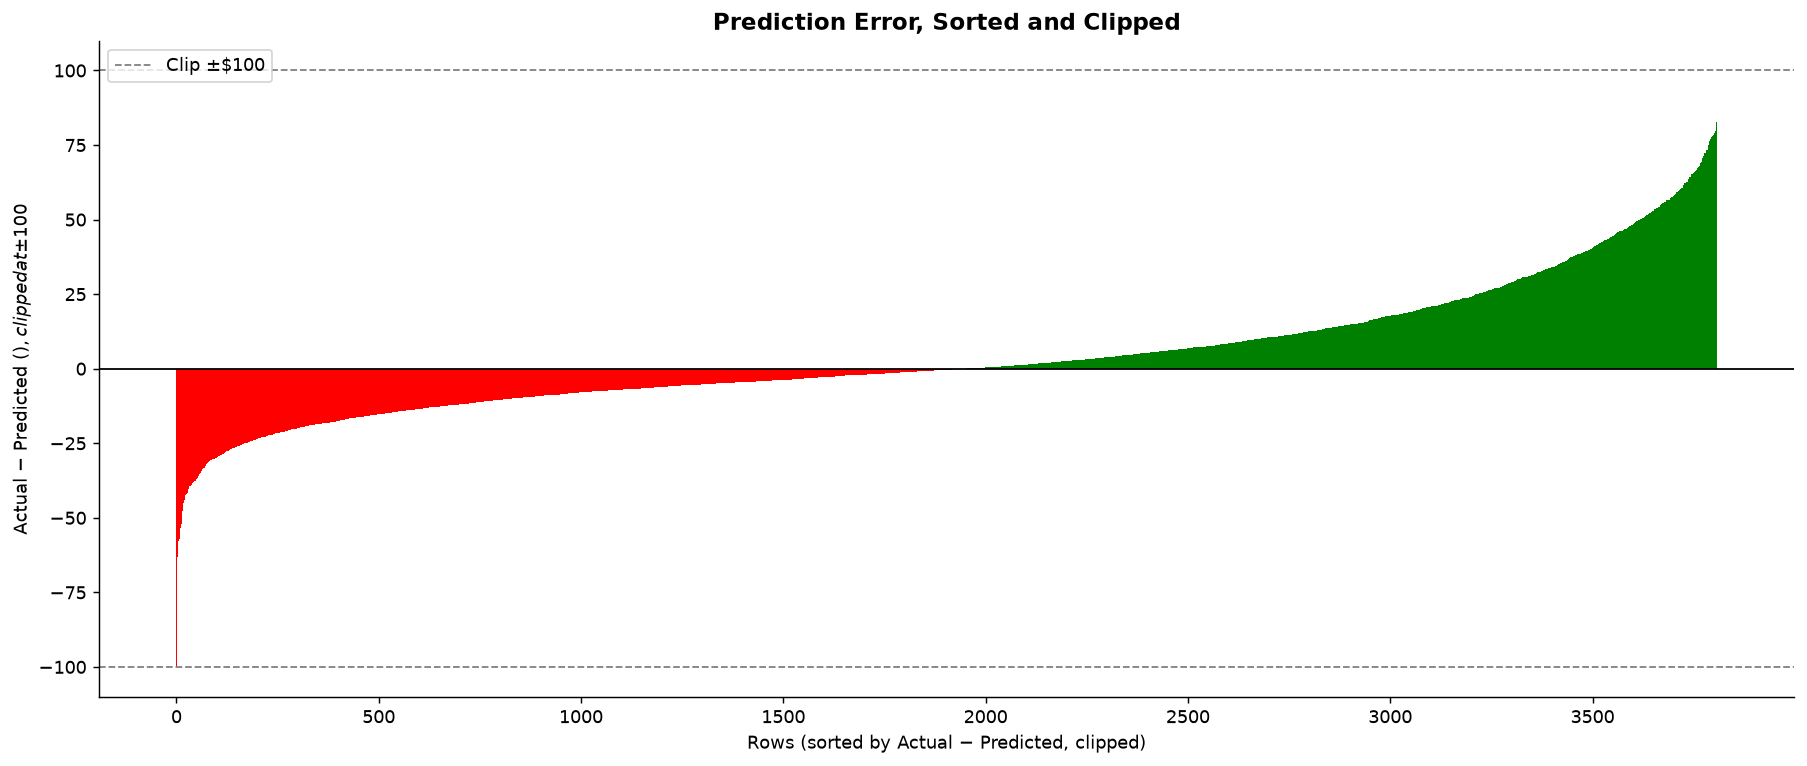

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Set your cap here — errors beyond this get clipped to the cap
# ============================================================
MAX_DIFF = 100   # adjust — try comparison['diff'].abs().quantile(0.95) to auto-pick

comparison['diff'] = comparison['actual'] - comparison['predicted']

# clip, don't drop — keeps every row, just caps the extreme values visually
comparison['diff_clipped'] = comparison['diff'].clip(-MAX_DIFF, MAX_DIFF)

n_clipped = (comparison['diff'].abs() > MAX_DIFF).sum()
print(f"Clipped {n_clipped} rows ({n_clipped/len(comparison):.1%}) beyond ±${MAX_DIFF:,}")

sorted_by_diff = comparison.sort_values('diff_clipped').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 6))

colors = ['red' if d < 0 else 'green' for d in sorted_by_diff['diff_clipped']]
ax.bar(sorted_by_diff.index, sorted_by_diff['diff_clipped'], color=colors, width=1.0)

# mark the clip boundaries so it's clear where clipping kicks in
ax.axhline(MAX_DIFF, color='gray', linestyle='--', linewidth=1, label=f'Clip ±${MAX_DIFF:,}')
ax.axhline(-MAX_DIFF, color='gray', linestyle='--', linewidth=1)
ax.axhline(0, color='black', linewidth=1)

ax.set_xlabel('Rows (sorted by Actual − Predicted, clipped)')
ax.set_ylabel(f'Actual − Predicted ($), clipped at ±${MAX_DIFF:,}')
ax.set_title('Prediction Error, Sorted and Clipped')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

## 8 Feature Importance

=== Budget model feature importance ===


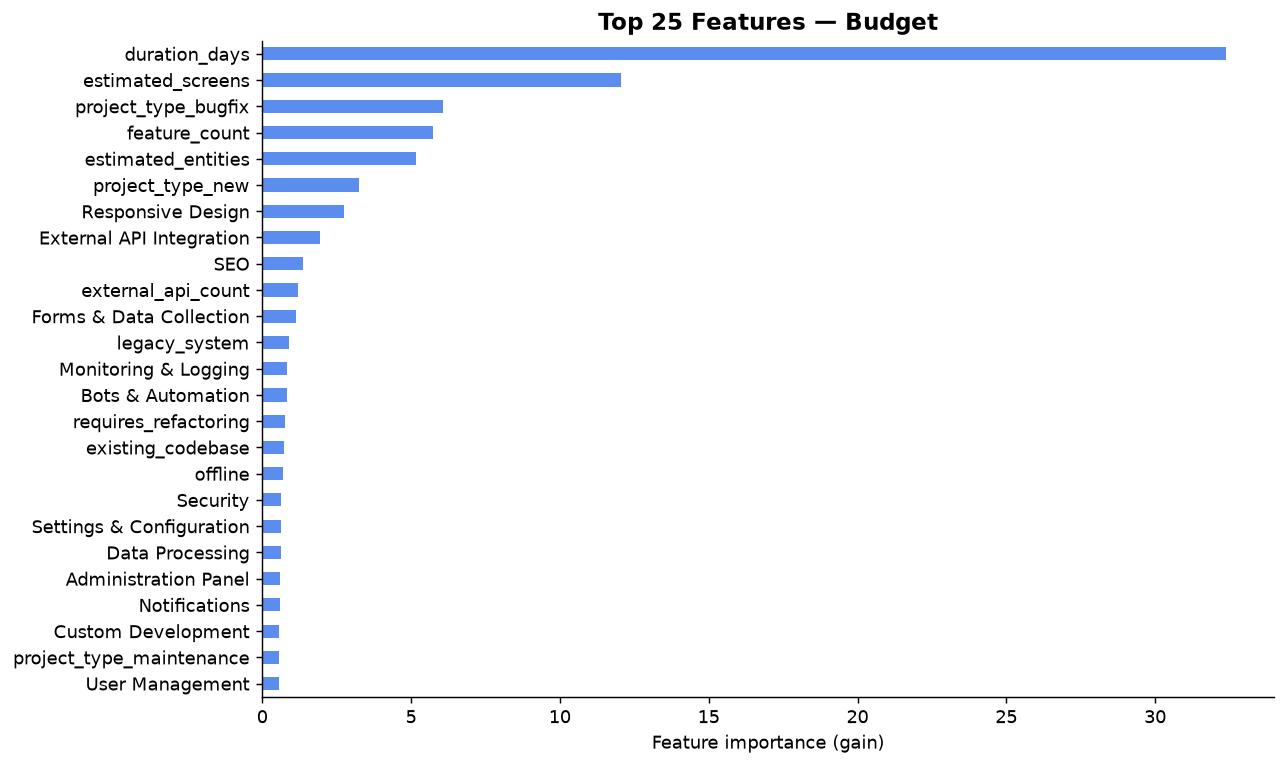

duration_days               32.374976
estimated_screens           12.044491
project_type_bugfix          6.070068
feature_count                5.738201
estimated_entities           5.175893
project_type_new             3.265656
Responsive Design            2.743514
External API Integration     1.936601
SEO                          1.373201
external_api_count           1.207848


In [ ]:
TOP_N = 25

def plot_importance(model, feature_names, title, top_n=TOP_N):
    if hasattr(model, 'feature_importances_'):
        imp = pd.Series(model.feature_importances_, index=feature_names)
    else:
        return
    imp = imp.nlargest(top_n)
    fig, ax = plt.subplots(figsize=(10, 6))
    imp[::-1].plot(kind='barh', ax=ax, color=ACCENT)
    ax.set_title(title)
    ax.set_xlabel('Feature importance (gain)')
    plt.tight_layout(); plt.show()
    return imp

print('=== Budget model feature importance ===')
imp_b = plot_importance(cat_none['model'], ALL_FEATURES, f'Top {TOP_N} Features — Budget')
print(imp_b.head(10).to_string())



## 9 · SHAP — per-prediction explanations
SHAP shows **why** the model made each prediction, not just which features matter on average.

Computing SHAP values for budget model...


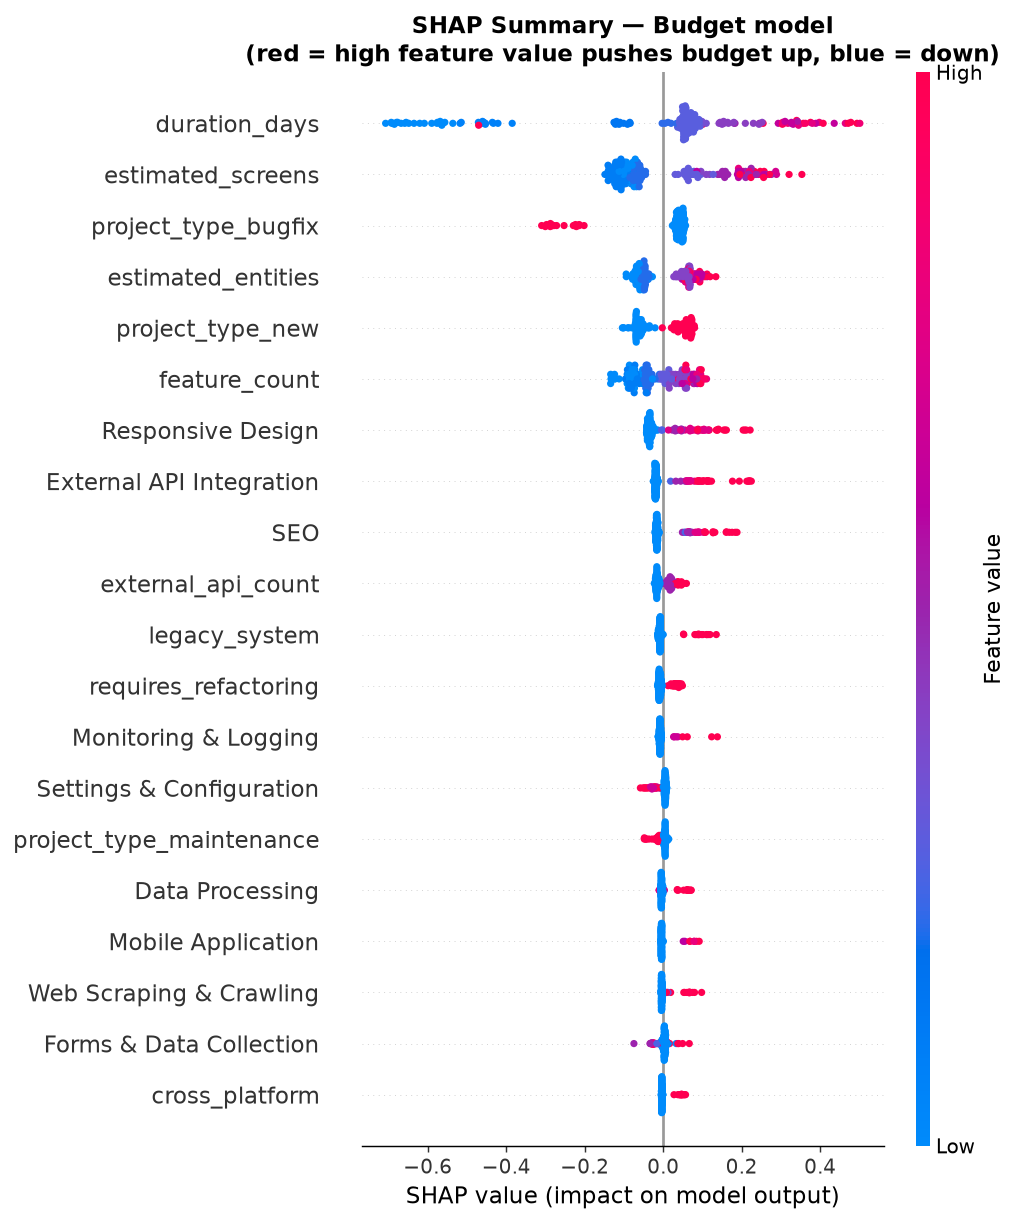

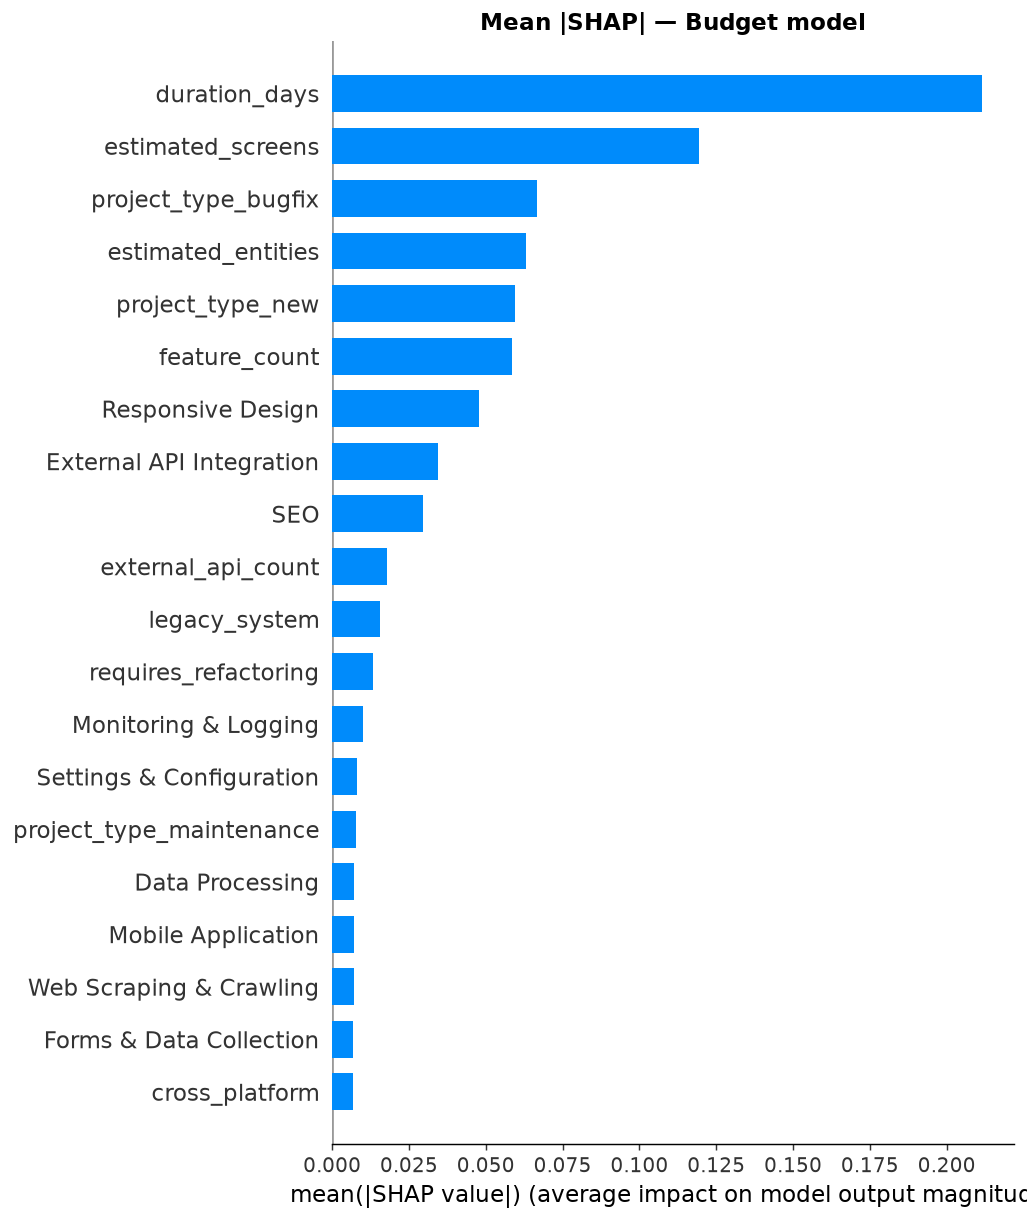


Explaining prediction for sample index 58 (predicted budget: 52)


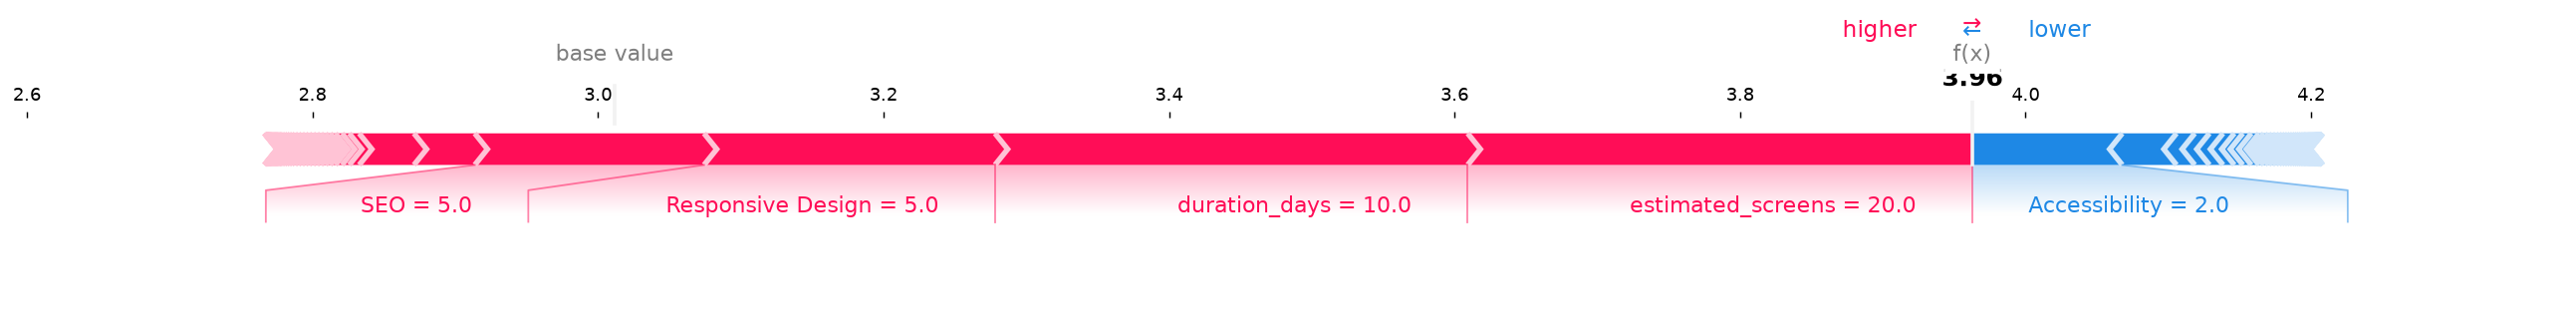

In [ ]:
# Use a subsample for speed (SHAP is O(n * features) per call)
SHAP_SAMPLE = min(200, len(X_te))
X_shap = X_te.sample(SHAP_SAMPLE, random_state=42)

print('Computing SHAP values for budget model...')
explainer_b = shap.TreeExplainer(cat_none['model'])
shap_vals_b = explainer_b.shap_values(X_shap)

# Summary plot — global view: which features drive predictions most?
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_vals_b, X_shap, feature_names=ALL_FEATURES,
                  max_display=20, show=False)
plt.title('SHAP Summary — Budget model\n(red = high feature value pushes budget up, blue = down)')
plt.tight_layout(); plt.show()

# Bar plot — mean |SHAP| per feature
shap.summary_plot(shap_vals_b, X_shap, feature_names=ALL_FEATURES,
                  plot_type='bar', max_display=20, show=False)
plt.title('Mean |SHAP| — Budget model')
plt.tight_layout(); plt.show()

# Single prediction explanation (most expensive predicted project)
idx = np.argmax(np.expm1(cat_none['model'].predict(X_shap)))
print(f'\nExplaining prediction for sample index {idx} '
      f'(predicted budget: {np.expm1(cat_none["model"].predict(X_shap.iloc[[idx]])[0]):,.0f})')
shap.force_plot(explainer_b.expected_value, shap_vals_b[idx], X_shap.iloc[idx],
                feature_names=ALL_FEATURES, matplotlib=True, show=False)
plt.tight_layout(); plt.show()

## 10. Embedding

In [16]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from tqdm.auto import tqdm
import numpy as np
import pandas as pd

# ==========================================================
# Parameters
# ==========================================================

EMBED_MODEL = "paraphrase-multilingual-MiniLM-L12-v2"      # multilingual
PCA_COMPONENTS = 64
BATCH_SIZE = 4

# ==========================================================
# Load embedding model
# ==========================================================

model = SentenceTransformer(
    "paraphrase-multilingual-MiniLM-L12-v2",
    device="cuda"
)

print(model.device)

# ==========================================================
# Encode descriptions
# ==========================================================

texts = (
    df["description"]
    .fillna("")
    .astype(str)
    .tolist()
)

embeddings = model.encode(
    texts,
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

print("Original embedding shape:", embeddings.shape)

# ==========================================================
# PCA
# ==========================================================

pca = PCA(
    n_components=PCA_COMPONENTS,
    random_state=42,
)

embeddings_pca = pca.fit_transform(embeddings)

print("Reduced shape:", embeddings_pca.shape)

print(
    f"Explained variance: "
    f"{pca.explained_variance_ratio_.sum():.2%}"
)

# ==========================================================
# Add to dataframe
# ==========================================================

emb_cols = [
    f"emb_{i}"
    for i in range(PCA_COMPONENTS)
]

emb_df = pd.DataFrame(
    embeddings_pca,
    columns=emb_cols,
    index=df.index,
)

df = pd.concat(
    [df, emb_df],
    axis=1,
)

print(df.shape)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2772.79it/s]


cuda:0


Batches:  93%|█████████▎| 2959/3173 [01:03<00:04, 46.42it/s]


KeyboardInterrupt: 

In [ ]:
# ============================================================
# Prepare train/test
# ============================================================
MODE="A"
df_model = transform_confidence(df, MODE)

ALL_FEATURES = [
    c
    for c in df.columns
    if c not in NON_FEATURE and df[c].dtype != object
]

X = df_model[ALL_FEATURES]
yB = df_model["log_target_budget"]

X_tr, X_te, yB_tr, yB_te = train_test_split(
    X,
    yB,
    test_size=0.30,
    random_state=42,
)

# print("\n-------------------")
# print(X_tr.head(2))

# print("\n=========")
# print(yB_tr.head(2))

print(f"Train shape: {X_tr.shape}  |  Test shape: {X_te.shape}")
print(X.shape)
print(df.columns.tolist())



Train shape: (8883, 194)  |  Test shape: (3808, 194)
(12691, 194)
['project_id', 'title', 'category', 'organization', 'created_at', 'scraped_date_created', 'usd_rate', 'usd_rate_date', 'final_budget', 'log_final_budget', 'final_budget_usd', 'log_final_budget_usd', 'budget_min', 'budget_max', 'log_budget_min', 'log_budget_max', 'budget_min_usd', 'budget_max_usd', 'log_budget_min_usd', 'log_budget_max_usd', 'budget_range_usd', 'budget_range_ratio', 'has_final_budget', 'duration', 'duration_days', 'description_length', 'description_word_count', 'skill_count', 'skills', 'description', 'outer_link', 'Authentication', 'Authorization & Role Management', 'User Management', 'User Profiles', 'Infrastructure & Operations', 'Administration Panel', 'Dashboard', 'Settings & Configuration', 'Content Management', 'Rich Text Editing', 'Media Management', 'Forms & Data Collection', 'File Upload & Storage', 'Document Management', 'Search', 'Filtering & Sorting', 'Import & Export', 'Reporting', 'Analytics

In [ ]:
cat_none = evaluate_catboost(
    X_tr,
    yB_tr,
    X_te,
    yB_te,
    "CatBoost_None",
    weight_mode="none",
)

0:	learn: 0.8939089	test: 0.8958123	best: 0.8958123 (0)	total: 12ms	remaining: 1m
100:	learn: 0.7479029	test: 0.7534757	best: 0.7534757 (100)	total: 1.25s	remaining: 1m
200:	learn: 0.7256372	test: 0.7381267	best: 0.7381267 (200)	total: 2.5s	remaining: 59.8s
300:	learn: 0.7113960	test: 0.7315714	best: 0.7315714 (300)	total: 3.77s	remaining: 58.9s
400:	learn: 0.7001109	test: 0.7277853	best: 0.7277853 (400)	total: 4.97s	remaining: 57s
500:	learn: 0.6897201	test: 0.7250548	best: 0.7250548 (500)	total: 6.38s	remaining: 57.3s
600:	learn: 0.6789913	test: 0.7233114	best: 0.7233114 (600)	total: 7.67s	remaining: 56.1s
700:	learn: 0.6689581	test: 0.7219130	best: 0.7219130 (700)	total: 8.86s	remaining: 54.4s
800:	learn: 0.6589547	test: 0.7207554	best: 0.7207554 (800)	total: 10.1s	remaining: 52.7s
900:	learn: 0.6492553	test: 0.7199514	best: 0.7199358 (899)	total: 11.1s	remaining: 50.4s
1000:	learn: 0.6400337	test: 0.7194365	best: 0.7194221 (998)	total: 12.2s	remaining: 48.6s
1100:	learn: 0.6313796	